# UdaSense: Optimized Object Recognition
## Notebook 2: Compression Techniques

 
In this notebook, you'll explore different model compression techniques to meet the requirements:
- The optimized model should be **30% smaller** than the baseline
- The optimized model should **reduce inference time by 40%**
- The optimized model should **maintain accuracy within 5%** of the baseline

You can experiment with different methods:
1. **Post-training**: Quantization, pruning, graph optimizations.
2. **In-training**: Quantization, pruning, distillation.
Optionally, you can choose to implement other techniques too.

Make sure to experiment with at least two different techniques. 
You will need to combine the selected techniques into a multi-step compression pipeline next, so make sure to select techniques that seem  promising individually but also combined.

### Step 1: Set up the environment

In [1]:
# Make sure that libraries are dynamically re-loaded if changed
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

In [2]:
import sys
from pathlib import Path

# Resolve the absolute path of the *project root* inside project-showroom
# Adjust `project_showroom_root` to your layout if needed
project_showroom_root = Path.cwd().resolve()

# Add the udasense project root to Python path
udasense_root = project_showroom_root # / "./"  # or whatever the folder is called
sys.path.insert(0, str(udasense_root))

print("Added to PYTHONPATH:", udasense_root)

# Set current working directory to udasense project root
%cd {udasense_root}
print("Current working directory:", Path.cwd())

Added to PYTHONPATH: /home/oliver/project-showroom/projects/model-opt/UdaSense-sense
/home/oliver/project-showroom/projects/model-opt/UdaSense-sense
Current working directory: /home/oliver/project-showroom/projects/model-opt/UdaSense-sense


In [3]:
# Import necessary libraries
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pprint
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from compression.post_training.pruning import prune_model
from compression.post_training.quantization import quantize_model
from compression.post_training.graph_optimization import optimize_model, verify_model_equivalence
from compression.in_training.distillation import train_with_distillation, MobileNetV3_Household_Small
from compression.in_training.pruning import train_with_pruning
from compression.in_training.quantization_fx import train_model_qat, QuantizableMobileNetV3_Household

from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP,TARGET_MODEL_COMPRESSION 
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, save_model, print_model_summary
from utils.visualization import plot_multiple_models_comparison
from utils.compression import (
    compare_experiments, compare_optimized_model_to_baseline, evaluate_optimized_model, list_experiments,  # For experimentation
    is_quantized  # For quantization
)

In [4]:
# Ignore PyTorch deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
warnings.filterwarnings("ignore", category=UserWarning)  # Optional: Ignore all user warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [5]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

Devices available: ['cpu', 'cuda:0 (NVIDIA GeForce RTX 4070 Laptop GPU)']


In [6]:
# Create directories for each technique
compression_types = [
    "post_training/pruning",
    "post_training/quantization",
    "post_training/graph_optimization",
    "in_training/distillation", 
    "in_training/quantization",
    "in_training/pruning",
]
for comp_type in compression_types:
    models_dir = f"./models/{comp_type}"
    models_ckp_dir = f"{models_dir}/checkpoints"
    results_dir = f"./results/{comp_type}"
    
    os.makedirs(models_ckp_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

In [6]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

### Step 2: Load the dataset

Extracting household classes from CIFAR100 for train set...
Extracting household classes from CIFAR100 for test set...
Input has size: (1, 3, 32, 32)
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


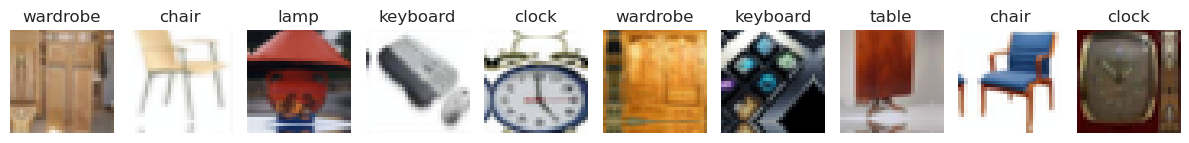


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


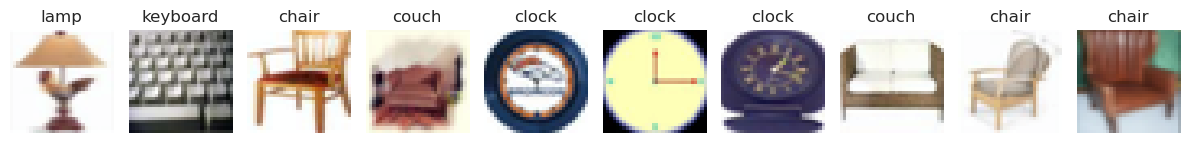

In [7]:
BATCH_SIZE = 64

# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=BATCH_SIZE, num_workers=4,
)

# Get input_size
input_size = get_input_size("CIFAR")
print(f"Input has size: {input_size}")

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

### Step 3: Load the baseline model and metrics

In [8]:
# Load the baseline model
baseline_model = MobileNetV3_Household()
baseline_model_name = "baseline_mobilenet"
baseline_model.load_state_dict(torch.load(f"./models/{baseline_model_name}/checkpoints/model.pth"))
print_model_summary(baseline_model)

# Load baseline metrics
with open(f"./results/{baseline_model_name}/metrics.json", "r") as f:
    baseline_metrics = json.load(f)

print("\nBaseline Model Metrics:")
pprint.pp(baseline_metrics)

# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
   

### Step 4: Implement and evaluate compression techniques

Now you'll implement and evaluate different compression techniques. For each technique that you choose, you'll:
1. Implement the technique
2. Evaluate its impact on model size, inference time, and accuracy
3. Analyze the trade-offs

To choose a technique, simply uncomment the apply_{TECHNIQUE_NAME}_technique() function call in the corresponding technique cell block.

#### 4.1 Post-Training - Quantization

Quantization reduces the precision of weights and activations, converting floating-point values to integers.


In [9]:
from compression.post_training.quantization import (
    quantize_model,
    QuantizableMobileNetV3_Household,
)

# Define a function to apply quantization and evaluate results
def apply_post_training_quantization(quantization_type, backend, device):
    """
    Apply quantization to a model with given method and backend.
    
    Args:
        quantization_type: Quantization method ("static" or "dynamic")
        backend: Backend for quantization ("fbgemm" for x86 or "qnnpack" for ARM)
        device: Which device to use for model loading, training, and evaluation
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/quantization/{quantization_type}"
    
    # Create experiment subdirectories
    os.makedirs(f"./models/{experiment_name}", exist_ok=True)
    os.makedirs(f"./results/{experiment_name}", exist_ok=True)
    
    print(f"Applying {quantization_type} quantization with {backend} backend")
    
    # Make a copy of the baseline model and move to specified device
    baseline_model = load_model(f"./models/{baseline_model_name}/checkpoints/model.pth").to(device)
    baseline_model.eval()
    
    # For static PTQ, wrap the model in QuantizableMobileNetV3_Household and fuse
    if quantization_type == "static":
        print("Wrapping baseline model in QuantizableMobileNetV3_Household for PTQ...")
        model_for_ptq = QuantizableMobileNetV3_Household(baseline_model).to("cpu")
        model_for_ptq.fuse_model()
    else:
        # For dynamic quantization we can just use the plain model
        model_for_ptq = baseline_model.to("cpu")

    # Apply post-training quantization   
    quantized_model = quantize_model(
        model_for_ptq,
        quantization_type=quantization_type,
        calibration_data_loader=train_loader if quantization_type == "static" else None,
        calibration_num_batches=len(train_loader) if quantization_type == "static" else None,  # Set this to the desired value
        backend=backend,
    )
    
    # Save the quantized model
    save_model(quantized_model, f"./models/{experiment_name}/model.pth")
    
    # Check that model is indeed quantized
    is_quantized(quantized_model)
    
    # Evaluate quantized model
    evaluate_optimized_model(
        quantized_model, test_loader, experiment_name, class_names, input_size, device=torch.device('cpu')
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        quantized_model,
        experiment_name,
        test_loader,
        class_names,
        device=torch.device('cpu'),
    )
    
    return quantized_model, comparison_results, experiment_name

#### Apply post-training quantization
## Find info at https://pytorch.org/docs/stable/quantization.html


Applying dynamic quantization with fbgemm backend
Applying dynamic quantization...
Dynamic quantization complete.
✅ Model is quantized

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:02<00:00,  7.52it/s]


Baseline metrics saved at ./results/post_training/quantization/dynamic/metrics.json.


Calculating confusion matrix: 100%|██████████| 16/16 [00:02<00:00,  7.15it/s]


Confusion matrix saved to ./results/post_training/quantization/dynamic/confusion_matrix.png


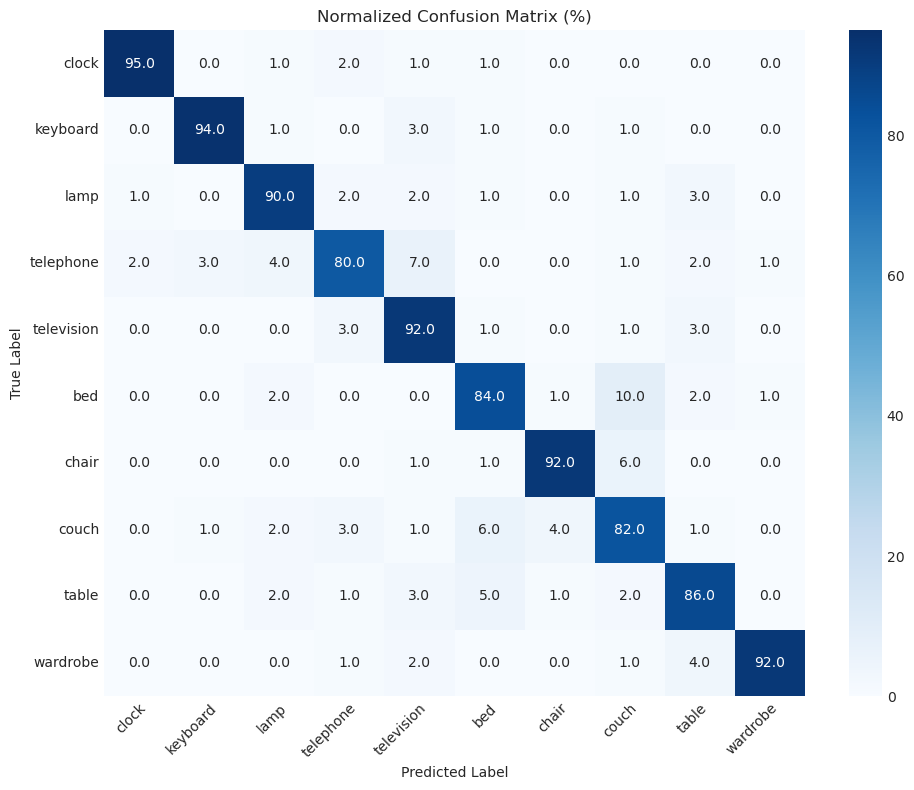


Optimized Model Metrics (post_training/quantization/dynamic):
Accuracy: 88.70%
Model Size: 4.24 MB
CPU Inference Time: 8.87 ms (112.73 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:02<00:00,  6.98it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:02<00:00,  6.03it/s]


Model comparison plot saved to ./results/post_training/quantization/dynamic/comparison.png


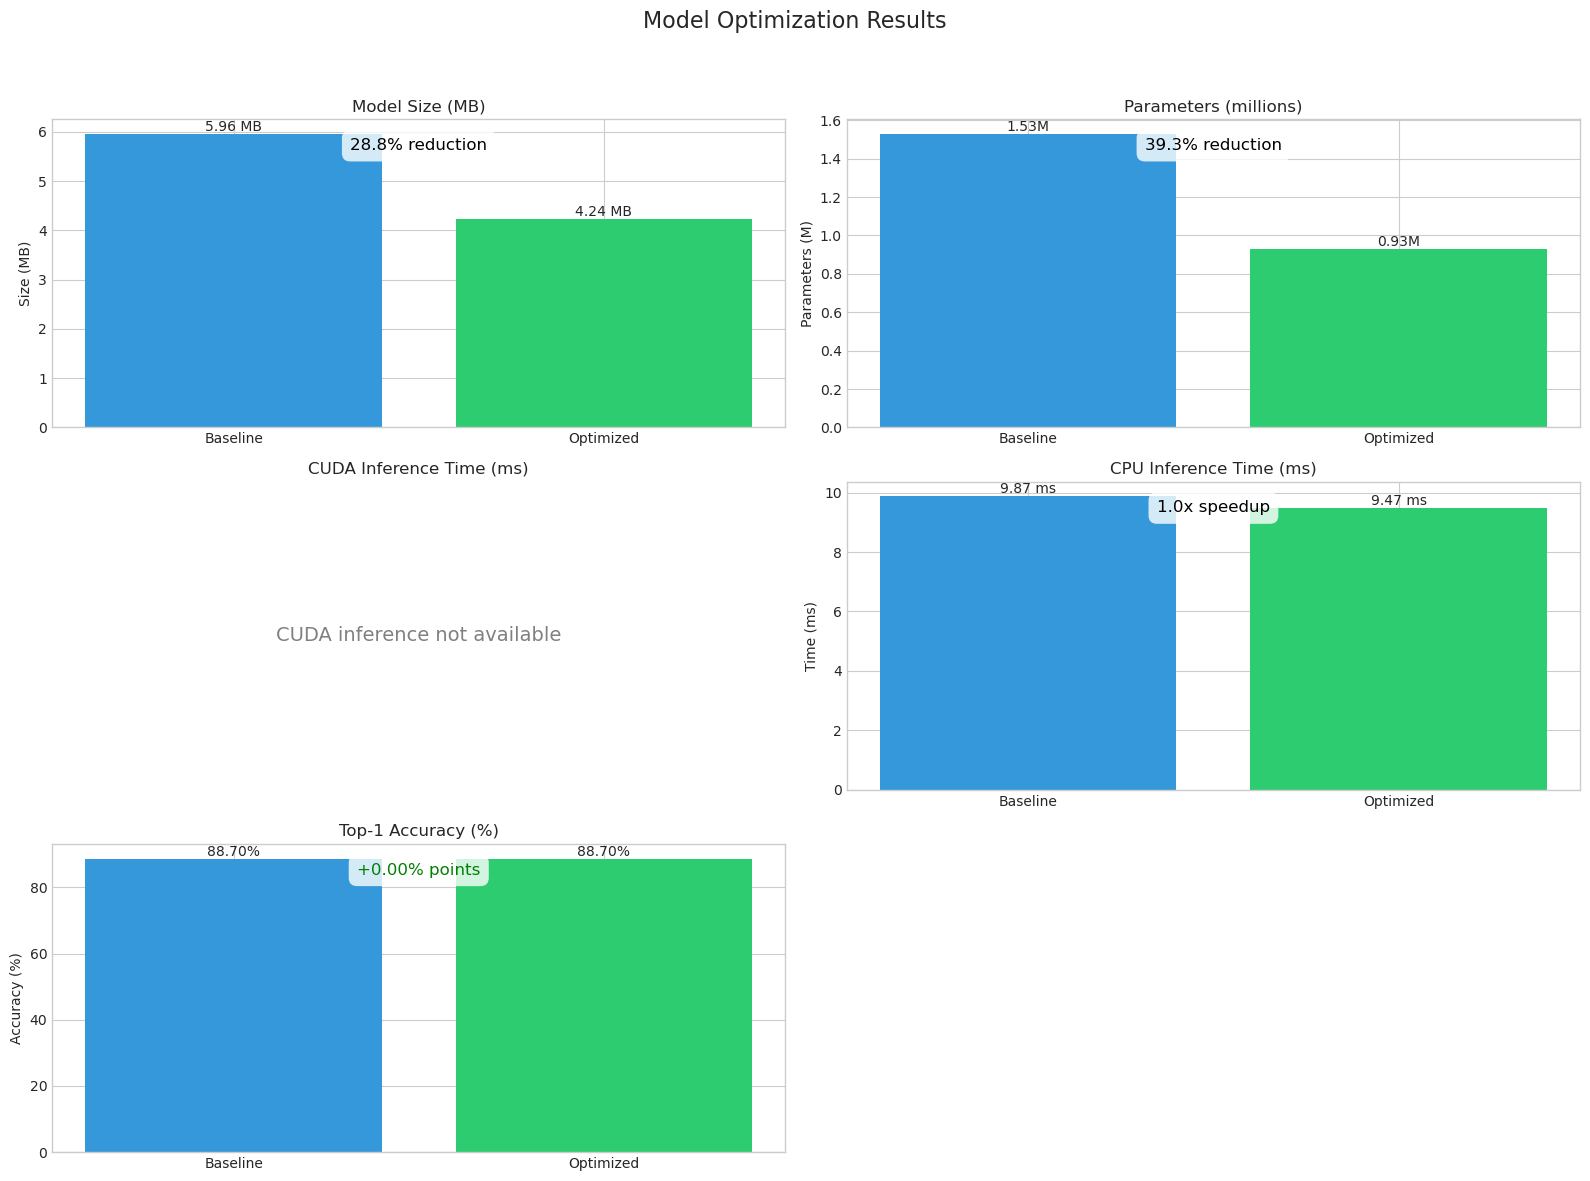


post_training/quantization/dynamic Results:
Model Size: 4.24 MB (28.8% reduction)
Parameters: 927,008 (39.3% reduction)
CPU Inference Time: 9.47 ms (1.0x speedup)
Accuracy: 88.70% (+0.00% change)
Requirements met: False


In [10]:
## Experiment with different configurations
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
quantization_type = "dynamic" # One of "dynamic" or "static"
backend = "fbgemm"  # One of "fbgemm" or "qnnpack"
device = torch.device("cpu")  # Define using torch.device()

# Optimize and evaluate model
quantized_model_dynamic, quantized_comparison_results, experiment_name = apply_post_training_quantization(quantization_type, backend=backend, device=device)

> See report at the end of the notebook for result interpretations.

Now we try out static quantization:

Applying static quantization with fbgemm backend
Wrapping baseline model in QuantizableMobileNetV3_Household for PTQ...
Fusing Conv+BN patterns in MobileNetV3_Household...
Layer fusion complete.
Applying static quantization with backend = fbgemm
Sum BatchNorm2d for original model: 34
Sum BatchNorm2d for prepared model: 0

<class 'torch.fx.graph_module.GraphModule.__new__.<locals>.GraphModuleImpl'>
opcode         name                                              target                                                      args                                                       kwargs
-------------  ------------------------------------------------  ----------------------------------------------------------  ---------------------------------------------------------  ------------------------------------------------------------------------------------------------------------------------------------------
placeholder    x                                                 x                   

Evaluating accuracy: 100%|██████████| 16/16 [00:01<00:00, 10.88it/s]


DEBUG[evaluate_model_metrics]: Completed accuracy evaluation.


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:01<00:00, 11.79it/s]


DEBUG[evaluate_per_class_accuracy]: Calculating per-class accuracy in evaluation function...
DEBUG[evaluate_per_class_accuracy]: Completed per-class accuracy calculation.
DEBUG[evaluate_model_metrics]: Completed per-class accuracy evaluations.
DEBUG[evaluate_model_metrics]: Completed inference time measurement.
DEBUG[evaluate_model_metrics]: Completed model size measurement.
DEBUG[evaluate_model_metrics]: Completed memory usage measurement.
Baseline metrics saved at ./results/post_training/quantization/static/metrics.json.


Calculating confusion matrix: 100%|██████████| 16/16 [00:02<00:00,  7.75it/s]


Confusion matrix saved to ./results/post_training/quantization/static/confusion_matrix.png


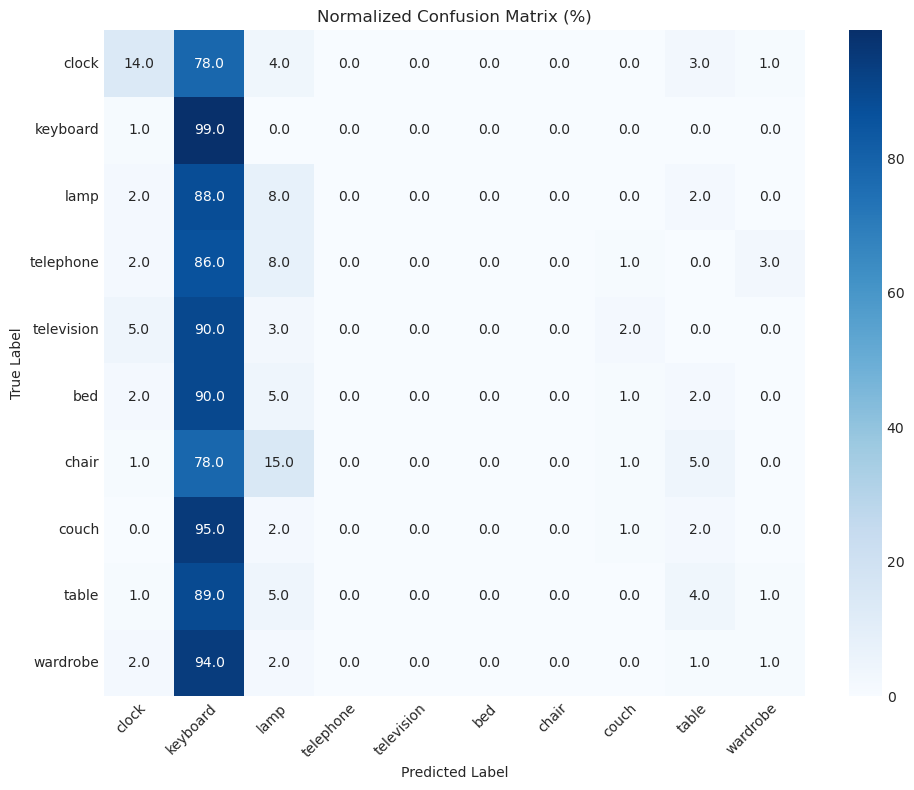


Optimized Model Metrics (post_training/quantization/static):
Accuracy: 12.30%
Model Size: 1.75 MB
CPU Inference Time: 12.69 ms (78.82 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating accuracy: 100%|██████████| 16/16 [00:02<00:00,  5.93it/s]


DEBUG[evaluate_model_metrics]: Completed accuracy evaluation.


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:03<00:00,  5.10it/s]


DEBUG[evaluate_per_class_accuracy]: Calculating per-class accuracy in evaluation function...
DEBUG[evaluate_per_class_accuracy]: Completed per-class accuracy calculation.
DEBUG[evaluate_model_metrics]: Completed per-class accuracy evaluations.
DEBUG[evaluate_model_metrics]: Completed inference time measurement.
DEBUG[evaluate_model_metrics]: Completed model size measurement.
DEBUG[evaluate_model_metrics]: Completed memory usage measurement.
Get metrics of optimized model...


Evaluating accuracy: 100%|██████████| 16/16 [00:01<00:00, 11.22it/s]


DEBUG[evaluate_model_metrics]: Completed accuracy evaluation.


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:01<00:00, 11.26it/s]


DEBUG[evaluate_per_class_accuracy]: Calculating per-class accuracy in evaluation function...
DEBUG[evaluate_per_class_accuracy]: Completed per-class accuracy calculation.
DEBUG[evaluate_model_metrics]: Completed per-class accuracy evaluations.
DEBUG[evaluate_model_metrics]: Completed inference time measurement.
DEBUG[evaluate_model_metrics]: Completed model size measurement.
DEBUG[evaluate_model_metrics]: Completed memory usage measurement.
Model comparison plot saved to ./results/post_training/quantization/static/comparison.png


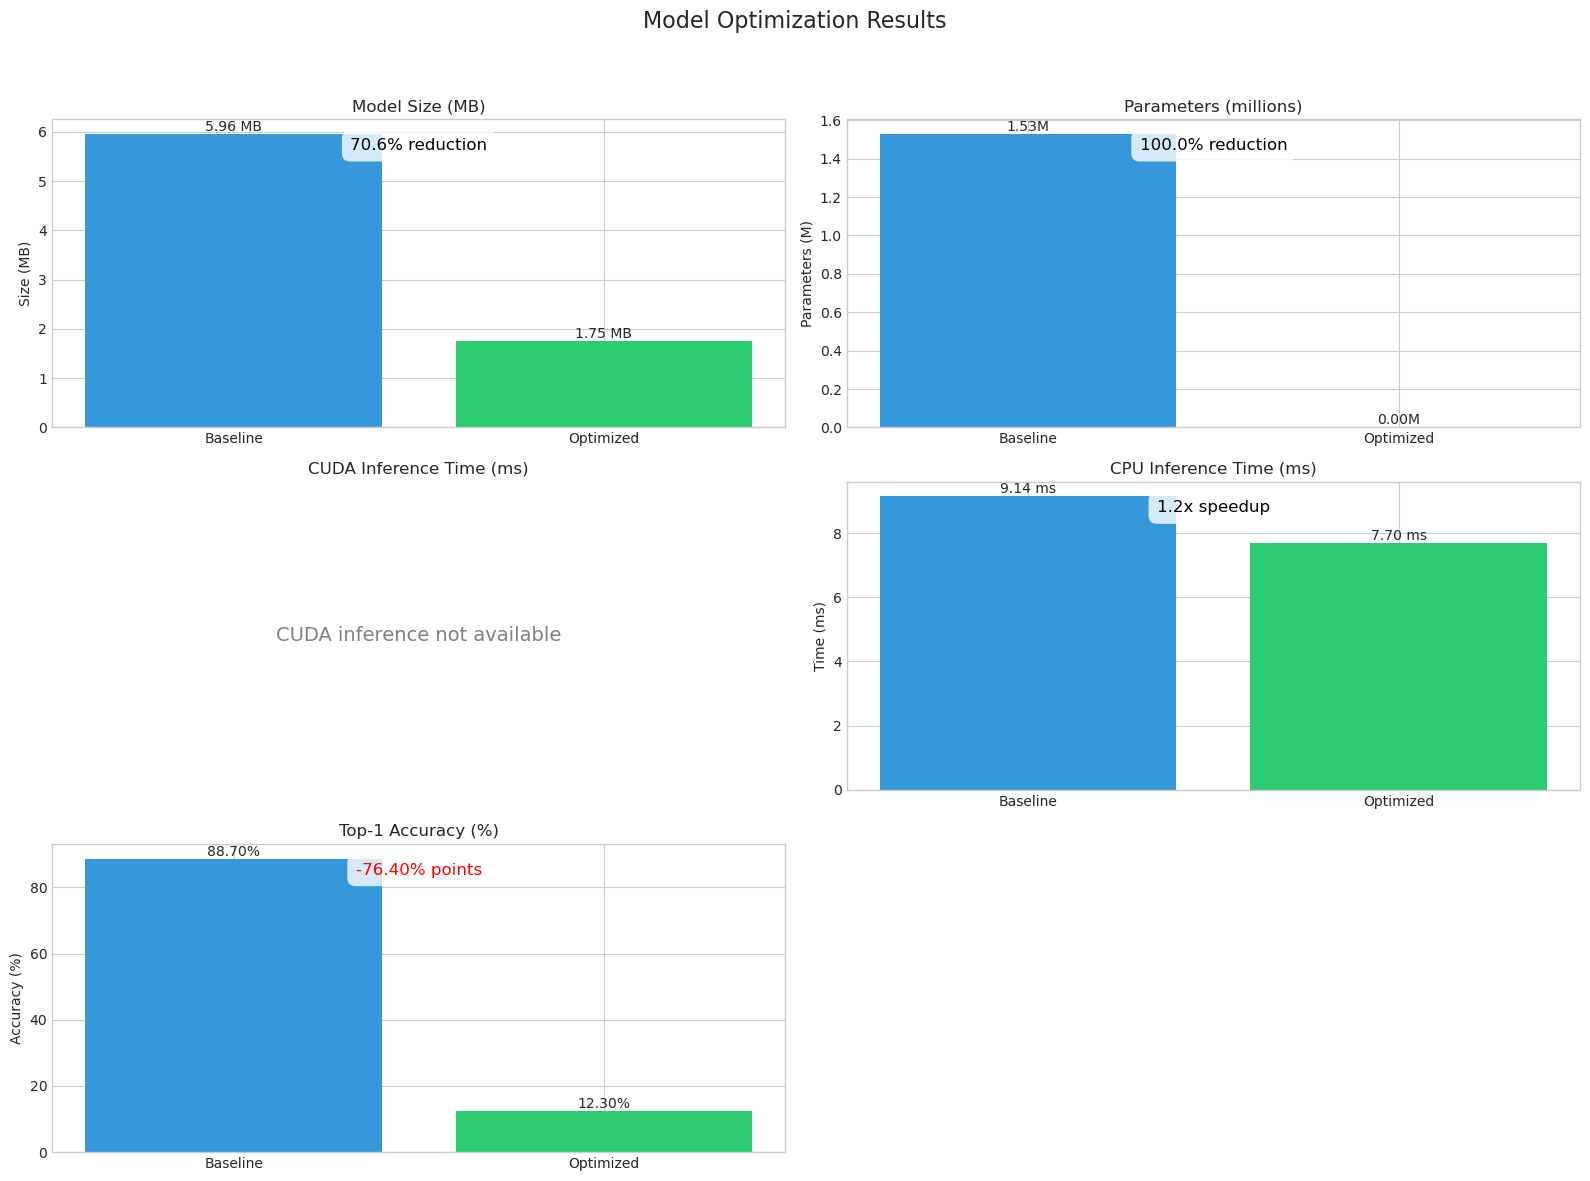


post_training/quantization/static Results:
Model Size: 1.75 MB (70.6% reduction)
Parameters: 0 (100.0% reduction)
CPU Inference Time: 7.70 ms (1.2x speedup)
Accuracy: 12.30% (-76.40% change)
Requirements met: False


In [17]:
## Experiment with different configurations
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
quantization_type = "static" # One of "dynamic" or "static"
backend = "fbgemm"  # One of "fbgemm" or "qnnpack"
device = torch.device("cpu")  # Define using torch.device()

# Optimize and evaluate model
quantized_model_static, quantized_comparison_results, experiment_name = apply_post_training_quantization(quantization_type, backend=backend, device=device)

> For results interpretation see report at the end of the notebook: [Failed Experiment: Full FX Static Quantization of MobileNetV3_Household](#failed-experiment-full-fx-static-quantization-of-mobilenetv3_household).

#### 4.2 In-training - Quantization

Quantization-aware training simulates quantization during training, allowing the model to adapt to the reduced precision.

In [20]:
# Define a function to apply quantization-aware training and evaluate results
def apply_quantization_aware_training(model, config, backend):
    """
    Apply quantization-aware training to a model.
    
    Args:
        model: The model architecture to quantize
        config: Dictionary containing the training configuration for the experiment
        backend: Backend for quantization ("fbgemm" for x86 or "qnnpack" for ARM)
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    qat_start_epoch, num_epochs = config['qat_start_epoch'], config['num_epochs']
    
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/quantization/epochs{num_epochs}_start{qat_start_epoch}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"./models/{experiment_name}", exist_ok=True)
    os.makedirs(f"./results/{experiment_name}", exist_ok=True)
    
    print(f"Applying quantization-aware training with QAT starting at epoch {qat_start_epoch} / ending at {num_epochs}")
        
    # Move model to specified device
    model = model.to(config['device'])
    
    # Train with QAT  
    quantized_model, qat_stats, qat_best_accuracy, qat_best_epoch = train_model_qat(
        model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"{os.getcwd()}/./models/{experiment_name}/checkpoints/",  # Providing full path to manage different sub-directory depths in utility scripts
        backend=backend,
    )
    
    print("DEBUG: Completed quantization-aware training.")
    
    # -----------------------------------
    # Free GPU memory before evaluation
    # -----------------------------------
    # 1) Ensure quantized model is on CPU
    quantized_model.cpu()

    # 2) If the original FP32 training model is no longer needed, drop references
    #    (it was passed in as `model` into train_model_qat)
    del model
    
    # If you have optimizer / scheduler objects still around, you can also delete them
    if "optimizer" in config:
        del config["optimizer"]
    if "scheduler" in config and config["scheduler"] is not None:
        del config["scheduler"]

    # 3) Clear CUDA cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # 4) Use CPU for evaluation
    device_for_inference = config.get("device_for_inference", torch.device("cpu"))

    # Save training statistics
    with open(f"./results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(qat_stats, f, indent=4)
    
    # Save the quantized model
    save_model(quantized_model, f"./models/{experiment_name}/model.pth")
    
    # Check that model is indeed quantized
    is_quantized(quantized_model)
    
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        quantized_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        is_in_training_technique=True,
        training_stats=qat_stats,
        device=device_for_inference,        
    )
    
    print("DEBUG: Optimized model was evaluated with QAT.")

    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        quantized_model,
        experiment_name,
        test_loader,
        class_names,
        device=device_for_inference,
    )
    
    return quantized_model, comparison_results, experiment_name

#### Apply quantization-aware training
## Find info at https://pytorch.org/docs/stable/quantization.html

Try it out:

Missing keys: []
Unexpected keys: []
Applying quantization-aware training with QAT starting at epoch 3 / ending at 100
Training with FX-based QAT for 100 epochs
QAT start epoch: 3, freeze BN / observers at epoch: 16
QAT backend: fbgemm


Epoch 1/1 [Test]: 100%|██████████| 16/16 [00:00<00:00, 32.04it/s, loss=0.556, acc=88.8]


DEBUG[QAT-FX]: pre-QAT baseline eval inside QAT loop: loss=0.4519, acc=88.80%


Epoch 1/100 [Test]: 100%|██████████| 16/16 [00:00<00:00, 49.90it/s, loss=0.662, acc=87.7]


Epoch 1/100 - Train Loss: 0.0482, Train Acc: 98.40%, Test Loss: 0.4548, Test Acc: 87.70%, LR: 0.001000, Time: 4.58s


...

DEBUG[evaluate_model_metrics]: Completed accuracy evaluation.


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:01<00:00,  9.54it/s]


DEBUG[evaluate_per_class_accuracy]: Calculating per-class accuracy in evaluation function...
DEBUG[evaluate_per_class_accuracy]: Completed per-class accuracy calculation.
DEBUG[evaluate_model_metrics]: Completed per-class accuracy evaluations.
DEBUG[evaluate_model_metrics]: Completed inference time measurement.
DEBUG[evaluate_model_metrics]: Completed model size measurement.
DEBUG[evaluate_model_metrics]: Completed memory usage measurement.
Baseline metrics saved at ./results/in_training/quantization/epochs100_start3/metrics.json.


Calculating confusion matrix: 100%|██████████| 16/16 [00:01<00:00,  9.38it/s]


Confusion matrix saved to ./results/in_training/quantization/epochs100_start3/confusion_matrix.png


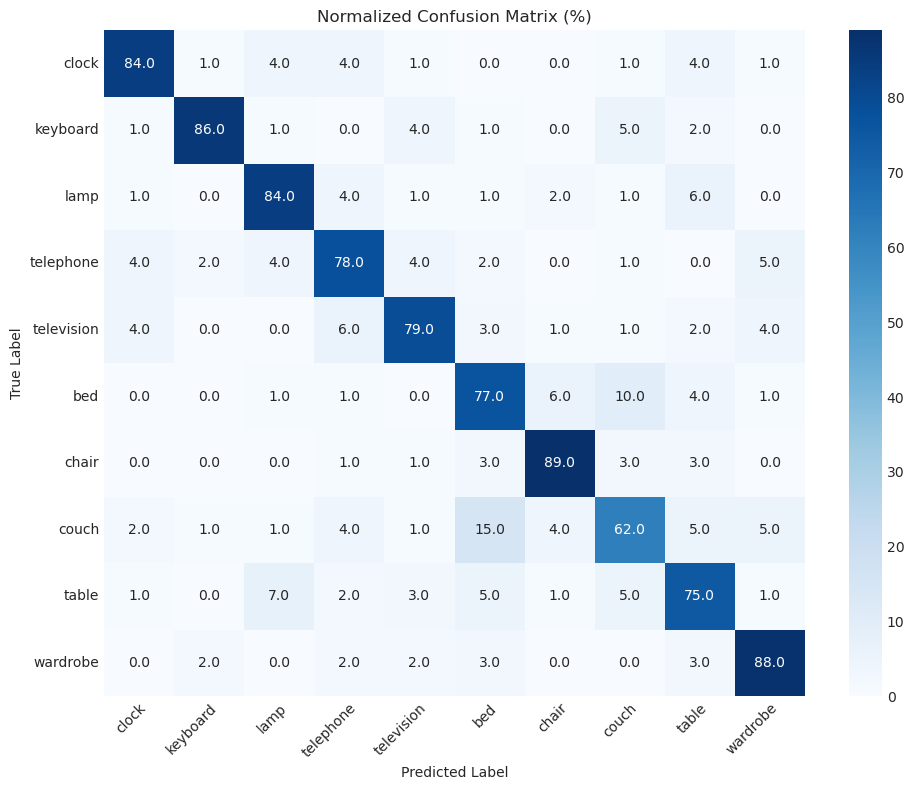

No suitable layers found for weight distribution visualization.
Training history plot saved to ./results/in_training/quantization/epochs100_start3/training_history.png


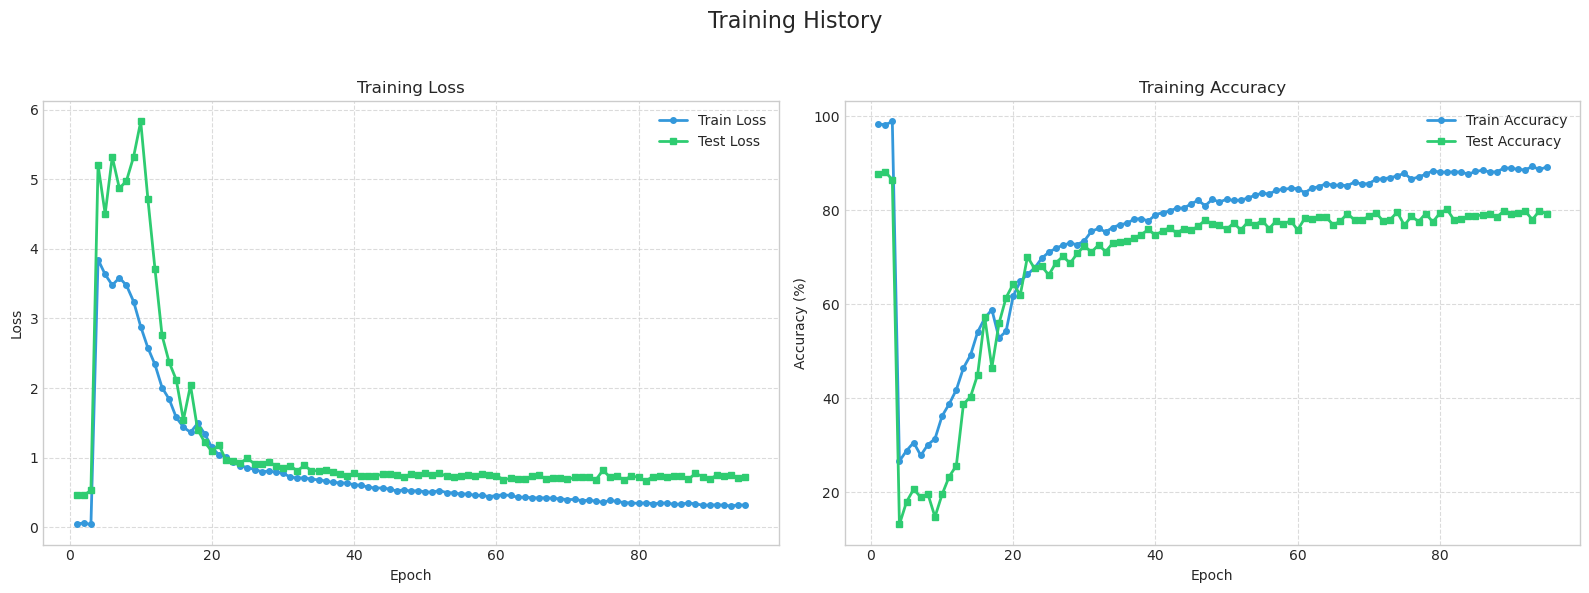


Optimized Model Metrics (in_training/quantization/epochs100_start3):
Accuracy: 80.00%
Model Size: 1.75 MB
CPU Inference Time: 17.62 ms (56.77 FPS)
DEBUG: Optimized model was evaluated with QAT.

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating accuracy: 100%|██████████| 16/16 [00:03<00:00,  5.02it/s]


DEBUG[evaluate_model_metrics]: Completed accuracy evaluation.


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:02<00:00,  5.62it/s]


DEBUG[evaluate_per_class_accuracy]: Calculating per-class accuracy in evaluation function...
DEBUG[evaluate_per_class_accuracy]: Completed per-class accuracy calculation.
DEBUG[evaluate_model_metrics]: Completed per-class accuracy evaluations.
DEBUG[evaluate_model_metrics]: Completed inference time measurement.
DEBUG[evaluate_model_metrics]: Completed model size measurement.
DEBUG[evaluate_model_metrics]: Completed memory usage measurement.
Get metrics of optimized model...


Evaluating accuracy: 100%|██████████| 16/16 [00:01<00:00,  9.47it/s]


DEBUG[evaluate_model_metrics]: Completed accuracy evaluation.


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:01<00:00,  9.45it/s]


DEBUG[evaluate_per_class_accuracy]: Calculating per-class accuracy in evaluation function...
DEBUG[evaluate_per_class_accuracy]: Completed per-class accuracy calculation.
DEBUG[evaluate_model_metrics]: Completed per-class accuracy evaluations.
DEBUG[evaluate_model_metrics]: Completed inference time measurement.
DEBUG[evaluate_model_metrics]: Completed model size measurement.
DEBUG[evaluate_model_metrics]: Completed memory usage measurement.
Model comparison plot saved to ./results/in_training/quantization/epochs100_start3/comparison.png


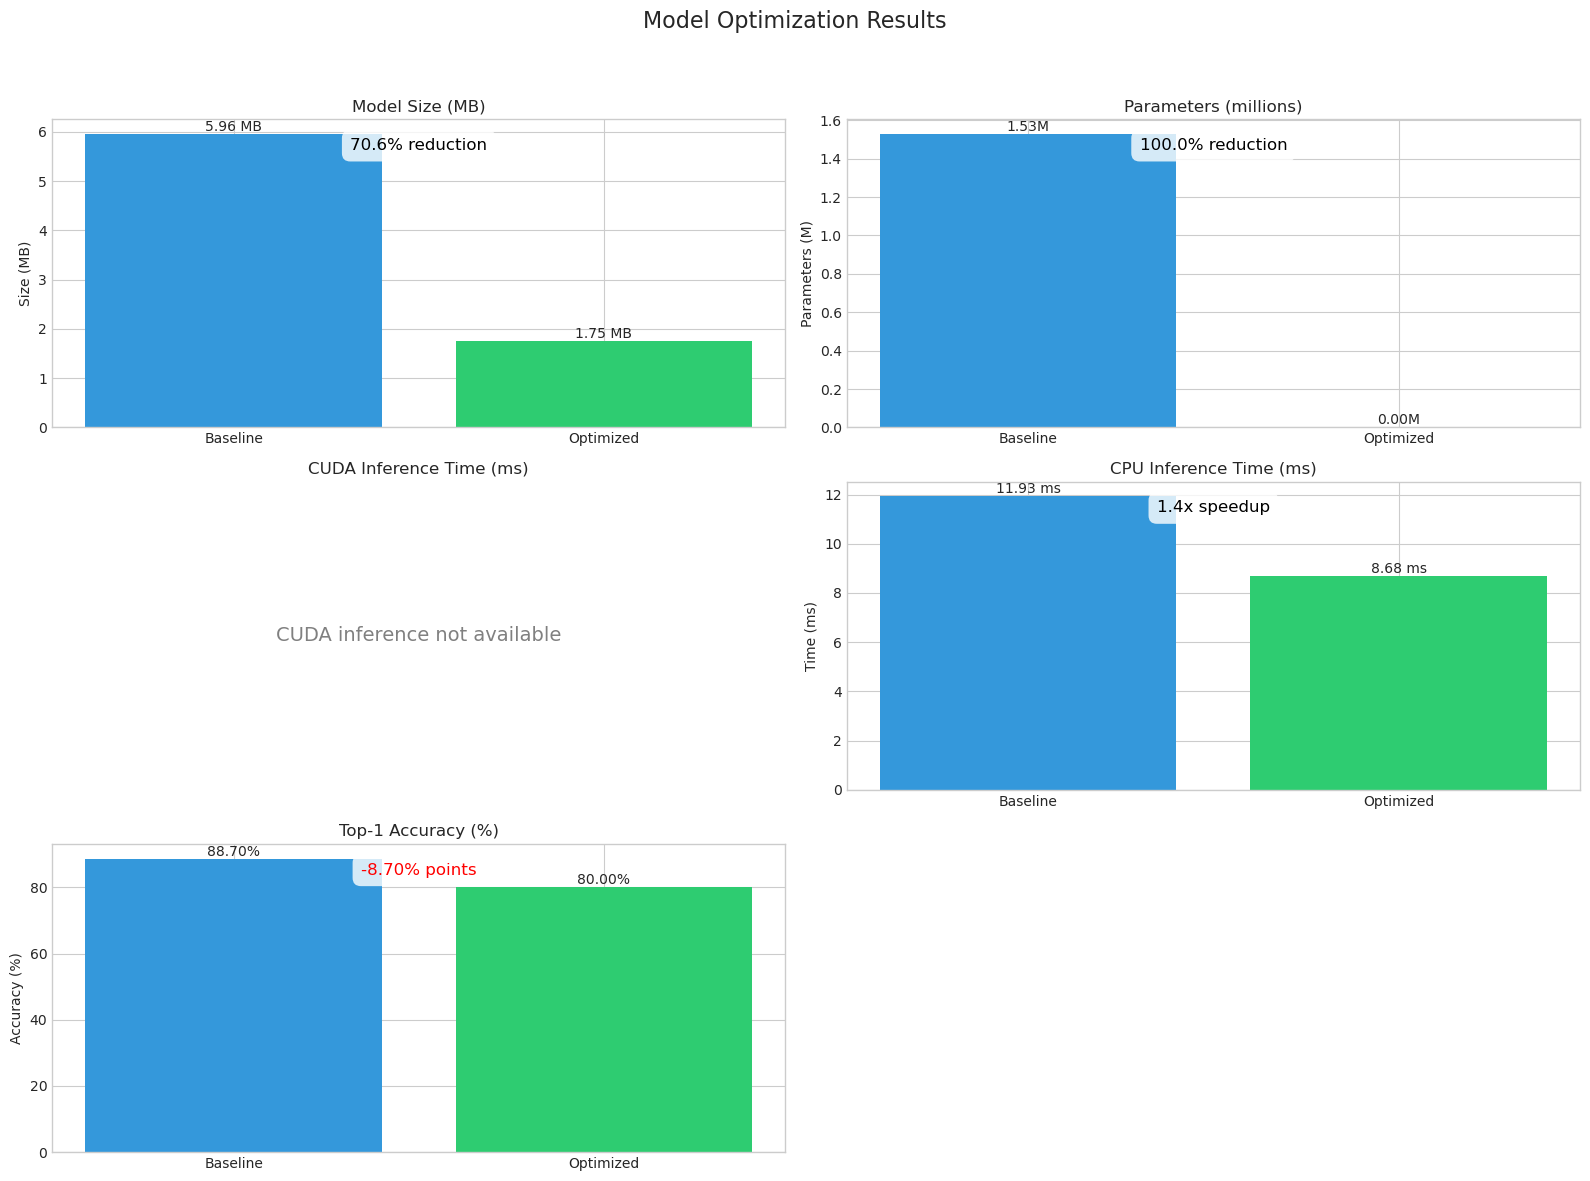


in_training/quantization/epochs100_start3 Results:
Model Size: 1.75 MB (70.6% reduction)
Parameters: 0 (100.0% reduction)
CPU Inference Time: 8.68 ms (1.4x speedup)
Accuracy: 80.00% (-8.70% change)
Requirements met: False


In [21]:
## Create quantizable model version
## The model with the fuse_model wrapper method called
model = QuantizableMobileNetV3_Household(quantize=False, pretrained=False)

# 2) Load baseline checkpoint
baseline_ckpt_path = "./models/baseline_mobilenet/checkpoints/model.pth"
state_dict = torch.load(baseline_ckpt_path, map_location="cpu")

# In case keys differ slightly, allow non strict and inspect warnings
missing, unexpected = model.load_state_dict(state_dict, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

optimizer = torch.optim.SGD(
        model.parameters(),
        lr=1e-3,                   # small LR, we are fine tuning a pretrained backbone
        momentum=0.9,
        weight_decay=1e-4,
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reasonable QAT config for this project
config = {
    # Epoch indices are zero based in the training loop
    # num_epochs = 25  → epochs 0..24
    # → warmup: epochs 0–4 (pure FP32)
    # → QAT active: from epoch 5
    # → freeze BN + observers: from epoch 12
    "qat_start_epoch": 3,          # start QAT after 5 FP32 warmup epochs
    "freeze_bn_epochs": 16,        # freeze BN stats and observers in the second half of training

    "num_epochs": 100,              # total training epochs (FP32 + QAT)

    "criterion": nn.CrossEntropyLoss(),

    # Conservative optimizer for fine tuning, not full training from scratch
    "optimizer": optimizer,

    # Scheduler that reacts to validation loss
    # "scheduler": torch.optim.lr_scheduler.ReduceLROnPlateau(
    #     optimizer=optimizer,            # will be set just below
    #     mode="min",
    #     factor=0.5,
    #     patience=3,
    # ),

    "patience": 15,                 # early stop if no improvement for 5 epochs

    "device": device,              # training device (likely CUDA)
    "device_for_inference": torch.device("cpu"),  # quantized model will run on CPU

    "grad_clip_norm": 2.0,         # mild gradient clipping to avoid spikes during QAT
}

backend = "fbgemm"  # One of "fbgemm" or "qnnpack"

# Optimize and evaluate model
qat_model, qat_comparison_results, experiment_name = apply_quantization_aware_training(model, config, backend)

#### 4.3 Post-training - Pruning

Pruning reduces model size by removing weights with small magnitudes that contribute less to the output.

In [ ]:
# Define a function to apply pruning and evaluate results
def apply_post_training_pruning(config):
    """
    Apply post-training pruning to a model with given pruning method and amount
    
    Args:
        config: Dictionary containing the configuration for the experiment
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    amount, pruning_method, device = config['amount'], config['pruning_method'], config['device']
    
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/pruning/{pruning_method}_{amount}_{device}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"./models/{experiment_name}", exist_ok=True)
    os.makedirs(f"./results/{experiment_name}", exist_ok=True)
    
    print(f"Applying post-training pruning with method {pruning_method} and amount {amount:.2f}")
    
    # Make a copy of the baseline model and move to specified device
    orig_model = load_model(f"./models/{baseline_model_name}/checkpoints/model.pth").to(device)
    orig_model.eval()
    
    # Apply post-training pruning
    pruned_model = prune_model(orig_model, pruning_method, amount, config["modules_to_prune"], config["custom_pruning_fn"])
    
    # Save the pruned model
    save_model(pruned_model, f"./models/{experiment_name}/model.pth")
    
    # Evaluate pruned model
    metrics, confusion_matrix = evaluate_optimized_model(
        pruned_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        pruned_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    
    return pruned_model, comparison_results, experiment_name


> Try it out:

Missing keys: []
Unexpected keys: []
Applying post-training pruning with method global_unstructured and amount 0.40
Pruning 54 modules with method: global_unstructured, amount: 0.4
Initial model sparsity: 0.00%
✅ Model is pruned
Final model sparsity: 39.90%
Model saved to ./models/post_training/pruning/global_unstructured_0-4_cpu/model.pth

Evaluating performance of optimized model...


Evaluating accuracy: 100%|██████████| 8/8 [00:02<00:00,  2.82it/s]


DEBUG[evaluate_model_metrics]: Completed accuracy evaluation.


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  2.99it/s]


DEBUG[evaluate_per_class_accuracy]: Calculating per-class accuracy in evaluation function...
DEBUG[evaluate_per_class_accuracy]: Completed per-class accuracy calculation.
DEBUG[evaluate_model_metrics]: Completed per-class accuracy evaluations.
DEBUG[evaluate_model_metrics]: Completed inference time measurement.
DEBUG[evaluate_model_metrics]: Completed model size measurement.
DEBUG[evaluate_model_metrics]: Completed memory usage measurement.
Baseline metrics saved at ./results/post_training/pruning/global_unstructured_0-4_cpu/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:02<00:00,  3.05it/s]


Confusion matrix saved to ./results/post_training/pruning/global_unstructured_0-4_cpu/confusion_matrix.png


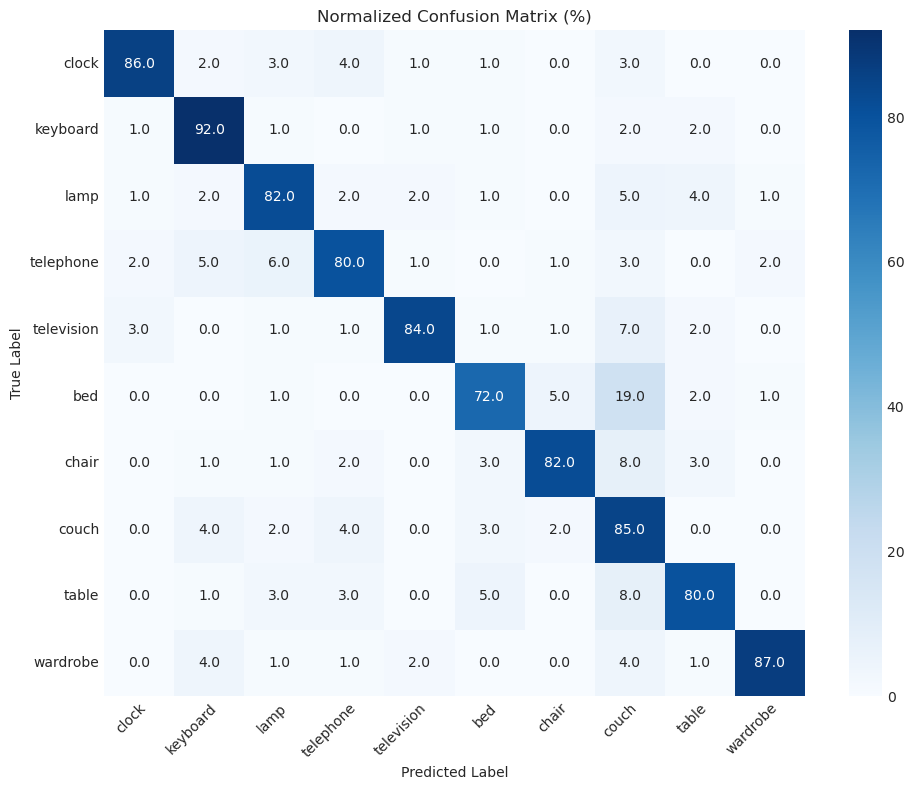


Optimized Model Metrics (post_training/pruning/global_unstructured_0-4_cpu):
Accuracy: 83.00%
Model Size: 5.96 MB
CPU Inference Time: 9.30 ms (107.58 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating accuracy: 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]


DEBUG[evaluate_model_metrics]: Completed accuracy evaluation.


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:03<00:00,  2.59it/s]


DEBUG[evaluate_per_class_accuracy]: Calculating per-class accuracy in evaluation function...
DEBUG[evaluate_per_class_accuracy]: Completed per-class accuracy calculation.
DEBUG[evaluate_model_metrics]: Completed per-class accuracy evaluations.
DEBUG[evaluate_model_metrics]: Completed inference time measurement.
DEBUG[evaluate_model_metrics]: Completed model size measurement.
DEBUG[evaluate_model_metrics]: Completed memory usage measurement.
Get metrics of optimized model...


Evaluating accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.09it/s]


DEBUG[evaluate_model_metrics]: Completed accuracy evaluation.


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:03<00:00,  2.18it/s]


DEBUG[evaluate_per_class_accuracy]: Calculating per-class accuracy in evaluation function...
DEBUG[evaluate_per_class_accuracy]: Completed per-class accuracy calculation.
DEBUG[evaluate_model_metrics]: Completed per-class accuracy evaluations.
DEBUG[evaluate_model_metrics]: Completed inference time measurement.
DEBUG[evaluate_model_metrics]: Completed model size measurement.
DEBUG[evaluate_model_metrics]: Completed memory usage measurement.
Model comparison plot saved to ./results/post_training/pruning/global_unstructured_0-4_cpu/comparison.png


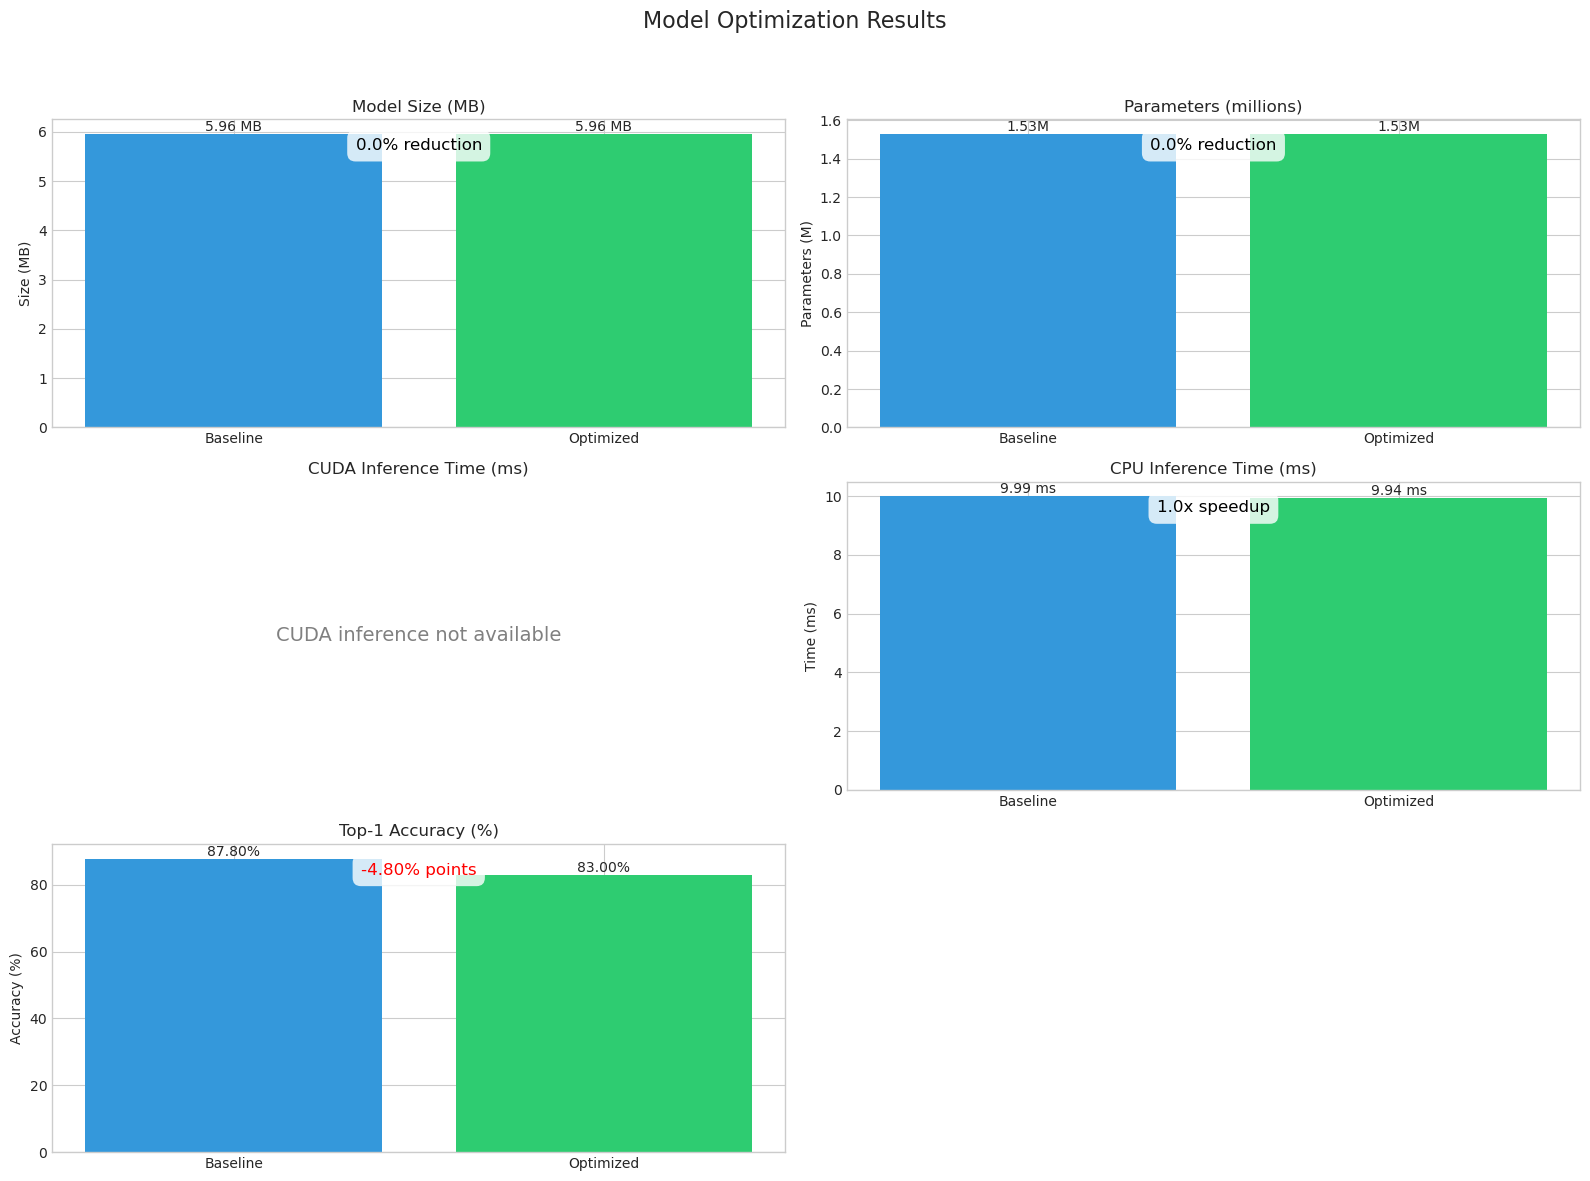


post_training/pruning/global_unstructured_0-4_cpu Results:
Model Size: 5.96 MB (0.0% reduction)
Parameters: 1,528,106 (0.0% reduction)
CPU Inference Time: 9.94 ms (1.0x speedup)
Accuracy: 83.00% (-4.80% change)
Requirements met: False


In [ ]:
# Apply post-training pruning    
## Find info at https://pytorch.org/tutorials/intermediate/pruning_tutorial.html

## Create quantizable model version
## The model with the fuse_model wrapper method called
model = QuantizableMobileNetV3_Household(quantize=False, pretrained=False)

# 2) Load baseline checkpoint
baseline_ckpt_path = "./models/baseline_mobilenet/checkpoints/model.pth"
state_dict = torch.load(baseline_ckpt_path, map_location="cpu")

# In case keys differ slightly, allow non strict and inspect warnings
missing, unexpected = model.load_state_dict(state_dict, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

## Experiment with different configurations
## We recommend testing pruning with various ratios
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
config = {
    'pruning_method': "global_unstructured", # random_unstructured, l1_unstructured, ln_structured, global_unstructured, custom
    'amount': 0.2,
    'modules_to_prune': None,
    'n': None,
    'dim': None,
    'custom_pruning_fn': None,
    'device': torch.device("cpu"),
}

structured_config = {
    "pruning_method": "ln_structured",
    "amount": 0.2,          # prune 20 percent of channels globally per layer
    "n": 2,                 # L2 norm for channel importance
    "dim": None,            # let helper choose: Conv2d dim=0, Linear dim=1
    "modules_to_prune": None,
    "custom_pruning_fn": None,
    "device": torch.device("cpu"),
}

global_unstructured_config = {
    "pruning_method": "global_unstructured",
    "amount": 0.4,          # prune 40 percent of weights globally
    "n": None,              # unused
    "dim": None,            # unused
    "modules_to_prune": None,
    "custom_pruning_fn": None,
    "device": torch.device("cpu"),
}

# Optimize and evaluate model
pruned_model, pruned_results, experiment_name = apply_post_training_pruning(global_unstructured_config)

#### 4.4 In-training - Pruning

Gradual pruning progressively prunes weights during training, allowing the model to adapt to increasing sparsity.

In [ ]:
# Define a function to apply pruning during training and evaluate results
def apply_in_training_pruning(model, config):
    """
    Apply gradual pruning during training.
    
    Args:
        model: The model architecture to quantize
        config: Dictionary containing the training configuration for the experiment
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    pruning_method, initial_sparsity, final_sparsity = config['pruning_method'], config['initial_sparsity'], config['final_sparsity'] 
    start_epoch, end_epoch = config['start_epoch'], config['end_epoch'] 
    device = config['device']
    
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/pruning/{pruning_method}_sparsity{initial_sparsity}-{final_sparsity}_epochs{start_epoch}-{end_epoch}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"./models/{experiment_name}", exist_ok=True)
    os.makedirs(f"./results/{experiment_name}", exist_ok=True)
    
    print(f"Applying gradual pruning from {initial_sparsity:.1%} to {final_sparsity:.1%} sparsity")
    
    # Move model to specified device
    model = model.to(device)
    
    # Train with gradual pruning
    # TODO: IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER 
    pruned_model, pruning_stats, pruned_best_accuracy, pruned_best_epoch = train_with_pruning(
        model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"./models/{experiment_name}/model.pth"
    )
    
    # Save training statistics
    with open(f"./results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(pruning_stats, f, indent=4)
    
    # Save the quantized model
    save_model(pruned_model, f"./models/{experiment_name}/model.pth")
    
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        pruned_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        is_in_training_technique=True,
        training_stats=pruning_stats,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        pruned_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    return pruned_model, comparison_results, experiment_name

# Apply in-training pruning 
## Find info at https://pytorch.org/tutorials/intermediate/pruning_tutorial.html

## Create a new model instance
model = MobileNetV3_Household()

## TODO: Experiment with different configurations
# We recommend testing pruning with various sparsity and epochs settings
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
config = {
    # General training config
    'num_epochs': None,  # Integer
    'criterion': None,  # A PyTorch loss  
    'optimizer': None,  # A PyTorch optimizer   
    'scheduler': None,  # A PyTorch scheduler
    'patience': None,  # Integer
    'device': None,  # Define with torch.device()
    'grad_clip_norm': None,  # Float
    # Pruning-specific config
    'initial_sparsity': None,  # Float
    'final_sparsity': None,    # Float
    'start_epoch': None,  # Integer
    'end_epoch': None,  # Integer  
    'pruning_frequency': None,  # Integer
    'pruning_method': None,  # String
    'schedule_type': None,  # String
    'only_prune_conv': None,  # Boolean
}
    
pruned_model, pruned_comparison_results, experiment_name = apply_in_training_pruning(model, config)

#### 4.5 In-training - Knowledge Distillation

Knowledge distillation trains a smaller student model to mimic a larger teacher model.

In [10]:
# Define a function to apply knowledge distillation and evaluate results
def apply_knowledge_distillation(teacher_model, student_model, config):
    """
    Apply knowledge distillation from a teacher model to a student model.
    
    Args:
        teacher_model: Pre-trained teacher model
        student_model: Smaller student model to train
        config: Dictionary containing the training configuration for the experiment
        
    Returns:
        Tuple of (distilled_student_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    temperature, alpha = config['temperature'], config['alpha']
    num_epochs = config['num_epochs']
    device = config['device']
    
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/distillation/temp{temperature}_alpha{alpha}_epochs{num_epochs}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"./models/{experiment_name}", exist_ok=True)
    os.makedirs(f"./results/{experiment_name}", exist_ok=True)
    
    print(f"Applying knowledge distillation with temperature={temperature} and alpha={alpha}")
    
    # Move models to specified device
    teacher_model = teacher_model.to(device)
    student_model = student_model.to(device)
    
    # Train student with knowledge distillation
    distilled_model, distillation_stats, best_accuracy, best_epoch = train_with_distillation(
        student_model,
        teacher_model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"./models/{experiment_name}/model.pth"
    )
    
    # Save training statistics
    with open(f"./results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(distillation_stats, f, indent=4)
    
    # Save the distilled student model
    save_model(distilled_model, f"./models/{experiment_name}/model.pth")
    
    # Evaluate distilled student model
    metrics, confusion_matrix = evaluate_optimized_model(
        distilled_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        is_in_training_technique=True,
        training_stats=distillation_stats,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        distilled_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    
    return distilled_model, comparison_results, experiment_name

> Try it out:

Applying knowledge distillation with temperature=2.0 and alpha=0.5
Student parameters: 1,002,154
Teacher parameters: 1,528,106
Training with knowledge distillation for 100 epochs
Temperature: 2.0, Alpha: 0.5


Epoch 1/100 [Test]: 100%|██████████| 16/16 [00:00<00:00, 45.78it/s, loss=3.75, acc=10] 


Epoch 1/100 - Train Loss: 4.5614, Train Acc: 25.24%, Test Loss: 2.3430, Test Acc: 10.00%, LR: 0.001000, Time: 4.94s
New best student model! Saving... (10.00%)
Model saved to ./models/in_training/distillation/temp2-0_alpha0-5_epochs100/model.pth


Epoch 2/100 [Test]: 100%|██████████| 16/16 [00:00<00:00, 46.84it/s, loss=3.95, acc=10] 


Epoch 2/100 - Train Loss: 3.9836, Train Acc: 35.00%, Test Loss: 2.4687, Test Acc: 10.00%, LR: 0.001000, Time: 4.73s


...

DEBUG[evaluate_model_metrics]: Completed accuracy evaluation.


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:00<00:00, 33.82it/s]


DEBUG[evaluate_per_class_accuracy]: Calculating per-class accuracy in evaluation function...
DEBUG[evaluate_per_class_accuracy]: Completed per-class accuracy calculation.
DEBUG[evaluate_model_metrics]: Completed per-class accuracy evaluations.
DEBUG[evaluate_model_metrics]: Completed inference time measurement.
DEBUG[evaluate_model_metrics]: Completed model size measurement.
DEBUG[evaluate_model_metrics]: Completed memory usage measurement.
Baseline metrics saved at ./results/in_training/distillation/temp2-0_alpha0-5_epochs100/metrics.json.


Calculating confusion matrix: 100%|██████████| 16/16 [00:03<00:00,  4.53it/s]


Confusion matrix saved to ./results/in_training/distillation/temp2-0_alpha0-5_epochs100/confusion_matrix.png


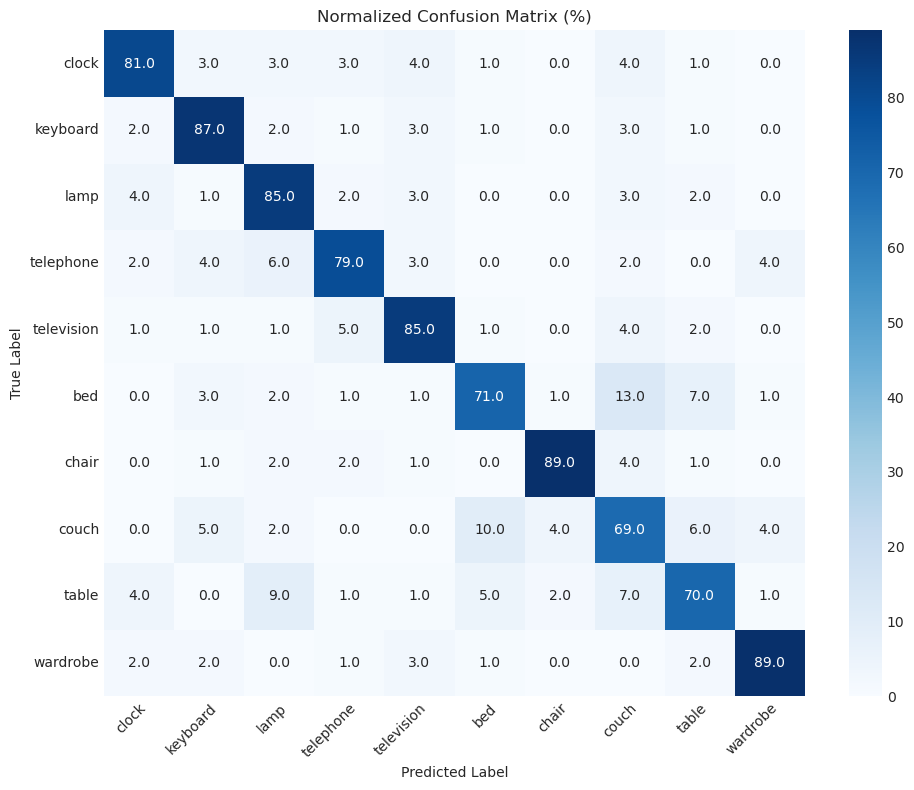

Weight distribution plot saved to ./results/in_training/distillation/temp2-0_alpha0-5_epochs100/weight_distribution.png


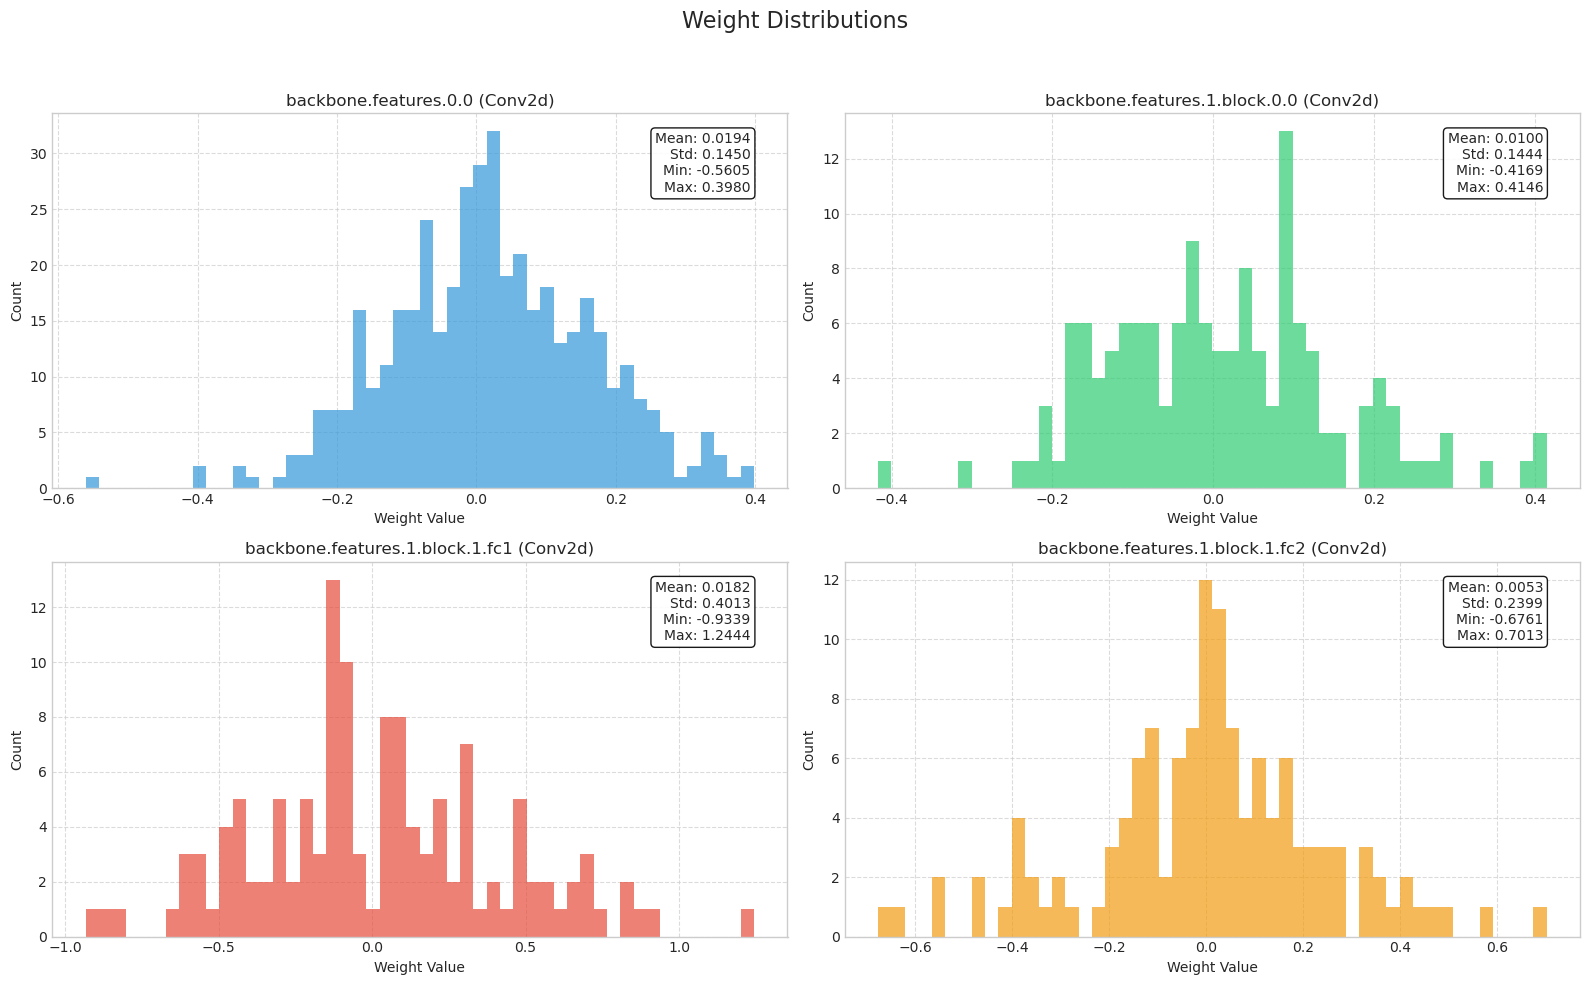

Training history plot saved to ./results/in_training/distillation/temp2-0_alpha0-5_epochs100/training_history.png


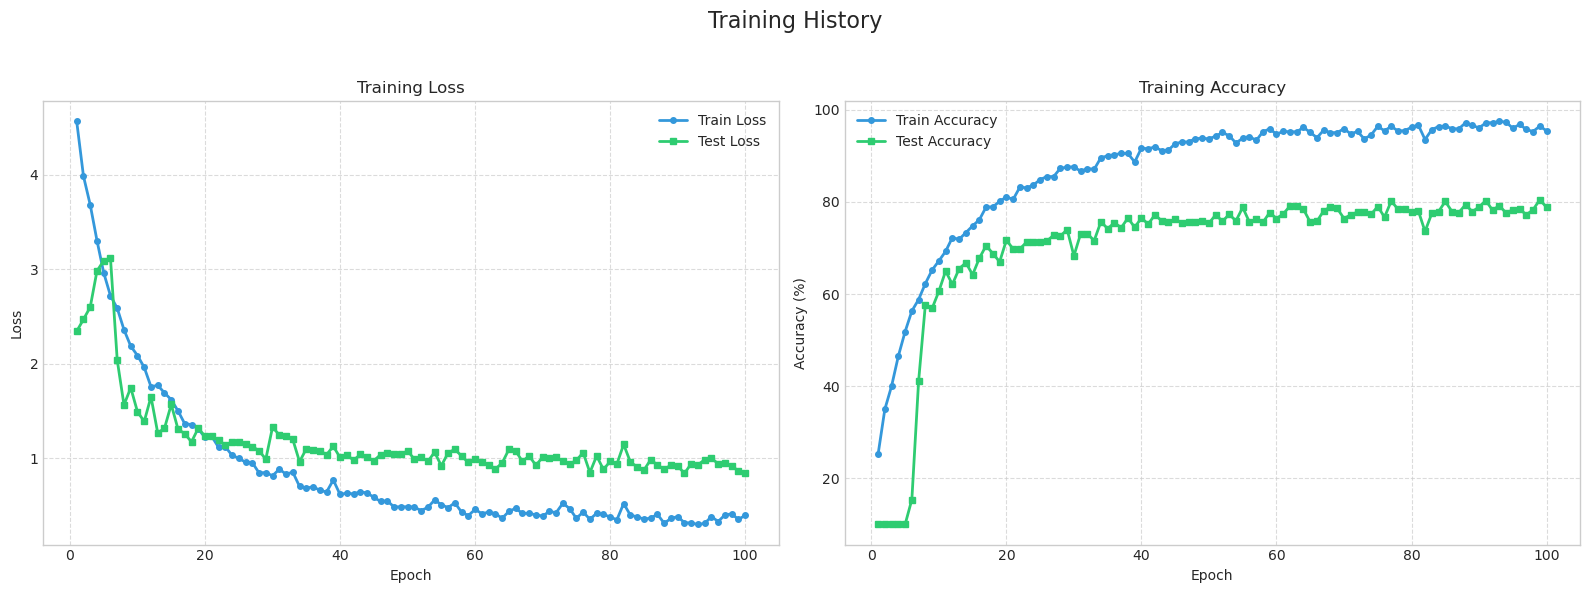


Optimized Model Metrics (in_training/distillation/temp2-0_alpha0-5_epochs100):
Accuracy: 80.50%
Model Size: 3.99 MB
CPU Inference Time: 18.54 ms (53.94 FPS)
CUDA Inference Time: 19.25 ms (51.94 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating accuracy: 100%|██████████| 16/16 [00:00<00:00, 42.19it/s]


DEBUG[evaluate_model_metrics]: Completed accuracy evaluation.


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:00<00:00, 34.58it/s]


DEBUG[evaluate_per_class_accuracy]: Calculating per-class accuracy in evaluation function...
DEBUG[evaluate_per_class_accuracy]: Completed per-class accuracy calculation.
DEBUG[evaluate_model_metrics]: Completed per-class accuracy evaluations.
DEBUG[evaluate_model_metrics]: Completed inference time measurement.
DEBUG[evaluate_model_metrics]: Completed model size measurement.
DEBUG[evaluate_model_metrics]: Completed memory usage measurement.
Get metrics of optimized model...


Evaluating accuracy: 100%|██████████| 16/16 [00:00<00:00, 35.81it/s]


DEBUG[evaluate_model_metrics]: Completed accuracy evaluation.


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:00<00:00, 36.40it/s]


DEBUG[evaluate_per_class_accuracy]: Calculating per-class accuracy in evaluation function...
DEBUG[evaluate_per_class_accuracy]: Completed per-class accuracy calculation.
DEBUG[evaluate_model_metrics]: Completed per-class accuracy evaluations.
DEBUG[evaluate_model_metrics]: Completed inference time measurement.
DEBUG[evaluate_model_metrics]: Completed model size measurement.
DEBUG[evaluate_model_metrics]: Completed memory usage measurement.
Model comparison plot saved to ./results/in_training/distillation/temp2-0_alpha0-5_epochs100/comparison.png


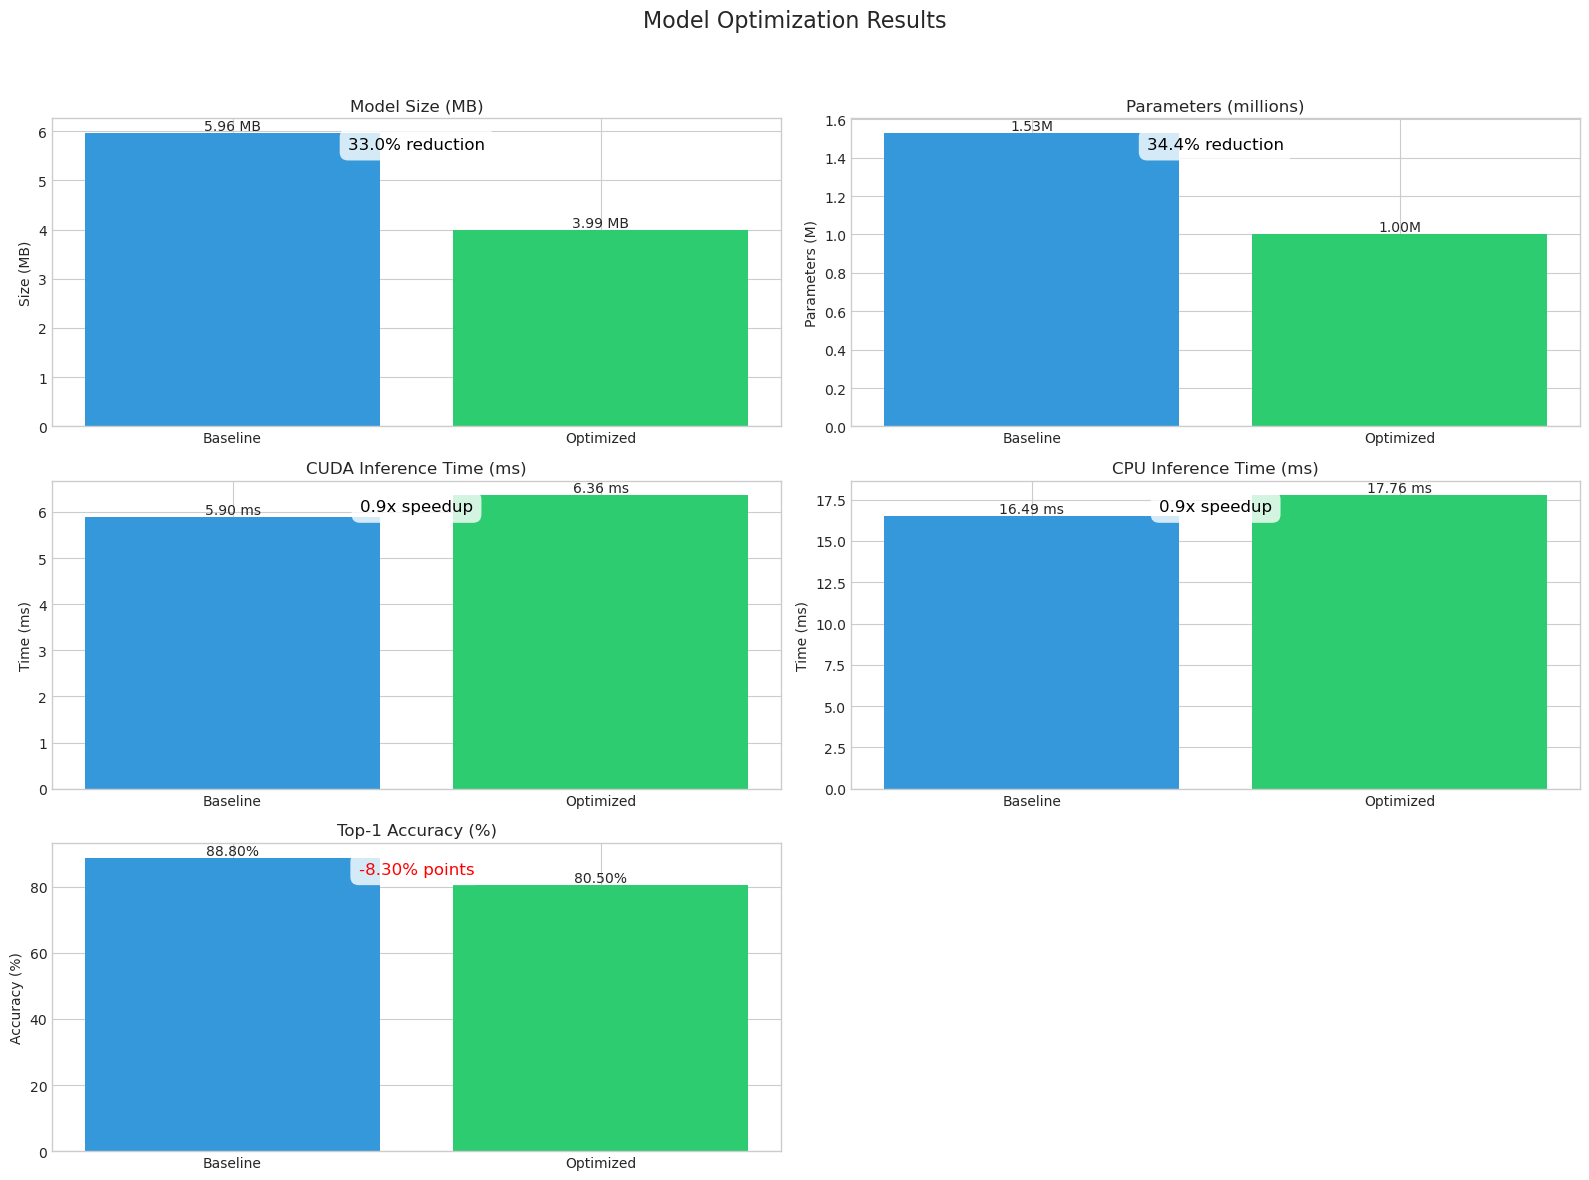


in_training/distillation/temp2-0_alpha0-5_epochs100 Results:
Model Size: 3.99 MB (33.0% reduction)
Parameters: 1,002,154 (34.4% reduction)
CPU Inference Time: 17.76 ms (0.9x speedup)
CUDA Inference Time: 6.36 ms (0.9x speedup)
Accuracy: 80.50% (-8.30% change)
Requirements met: False


In [15]:
# Apply knowledge distillation
## Find more info at https://pytorch.org/tutorials/beginner/knowledge_distillation_tutorial.html

## Load the pre-trained teacher model
teacher_model = load_model(f"./models/{baseline_model_name}/checkpoints/model.pth")
teacher_model.eval()  # Teacher should be in eval mode

config = {
    # High level
    "experiment_name": "kd_mobilenetv3_student_w0_6_ls256",

    # Student architecture
    "num_classes": 10,
    "width_mult": 1.0,
    "linear_size": 128,
    "dropout": 0.2,

    # "num_classes": 10,
    # "width_mult": 0.75,
    # "linear_size": 512,
    # "dropout": 0.2,

    # Training setup
    "num_epochs": 100,
    "batch_size": BATCH_SIZE,          # only used if you construct loaders here
    "optimizer": None, # will be set later

    # Hard-label criterion (used in validate_single_epoch and
    # optionally passed into the KD loss if you want)
    "criterion": nn.CrossEntropyLoss(),
    "grad_clip_norm": None,

    # Scheduler / early stopping
    "scheduler": None,
    "patience": 15,

    # Knowledge distillation specific
    "temperature": 2.0,            # softens teacher predictions
    "alpha": 0.5,                  # 0.5 distillation, 0.5 hard CE
}

## Create student model
student_model = MobileNetV3_Household_Small(
    num_classes=config["num_classes"],
    width_mult=config["width_mult"],
    linear_size=config["linear_size"],
    dropout=config["dropout"]
)

optimizer = optim.Adam(
        student_model.parameters(),
        lr=1e-3,
        weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=20,
        gamma=0.1
    )

#config['scheduler'] = scheduler
config['optimizer'] = optimizer
config['device'] = torch.device("cuda" if torch.cuda.is_available() else "cpu")

distilled_model, distilled_comparison_metrics, experiment_name = apply_knowledge_distillation(teacher_model, student_model, config)

#### 4.6 In-training - Graph Optimizations

Graph optimizations fuse operations and remove redundant nodes for better inference performance.

In [13]:
# Define a function to apply graph optimization and evaluate results
def apply_graph_optimization(optimization_method, input_shape=(1, 3, 32, 32), device=torch.device('cpu')):
    """
    Apply graph optimization to a model.
    
    Args:
        optimization_method: Optimization method to use in ["torchscript", "torch_fx"]
        input_shape: Shape of input tensor
        device: Which device to optimize the model on
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Check optimization method is supported
    if optimization_method not in ["torchscript", "torch_fx"]:
        raise ValueError(f"Unsupported optimization method: {optimization_method}")
    
    # Force CPU for FX graph optimization
    if optimization_method == "torch_fx":
        device_for_opt = torch.device("cpu")
    else:
        device_for_opt = device

    # Define unique experiment name given main parameters
    experiment_name = f"post_training/graph_optimization/{optimization_method}_{device_for_opt}"
    # Create experiment subdirectories
    os.makedirs(f"./models/{experiment_name}", exist_ok=True)
    os.makedirs(f"./results/{experiment_name}", exist_ok=True)
    
    print(f"Applying optimization with {optimization_method} as method")
    
    # Make a copy of the baseline model and move to specified device
    orig_model = load_model(f"./models/{baseline_model_name}/checkpoints/model.pth").to(device_for_opt)
    
    # Apply graph optimization
    optimized_model, serializable_model = optimize_model(
        orig_model,
        optimization_method=optimization_method,
        input_shape=input_shape,
        device=device_for_opt,
    )
    
    # Save the optimized model
    file_extension = ".pth" if optimization_method=="torch_fx" else ".pt"

    # Here it is important that we save the model without optimize_for_inference called
    save_model(serializable_model, f"./models/{experiment_name}/model{file_extension}")
    
    # Verify model equivalence
    is_equivalent = verify_model_equivalence(
        orig_model, 
        optimized_model, 
        input_shape=input_shape, 
        device=device_for_opt
    )
 
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        optimized_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        device=device_for_opt,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        optimized_model,
        experiment_name,
        test_loader,
        class_names,
        device=device_for_opt,
    )
    
    return optimized_model, comparison_results, experiment_name

> Try it out:

Applying optimization with torchscript as method
Original and optimized models produce equivalent outputs.

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:01<00:00,  9.13it/s]


Baseline metrics saved at ./results/post_training/graph_optimization/torchscript_cpu/metrics.json.


Calculating confusion matrix: 100%|██████████| 16/16 [00:01<00:00,  8.31it/s]


Confusion matrix saved to ./results/post_training/graph_optimization/torchscript_cpu/confusion_matrix.png


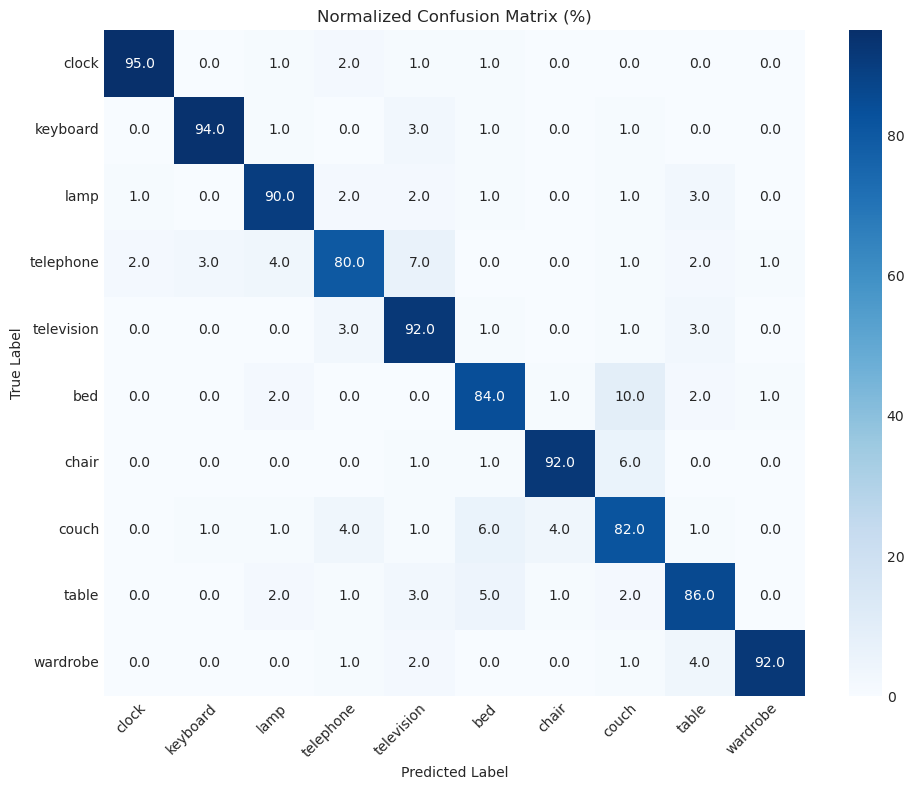


Optimized Model Metrics (post_training/graph_optimization/torchscript_cpu):
Accuracy: 88.70%
Model Size: 2.30 MB
CPU Inference Time: 11.99 ms (83.42 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:03<00:00,  4.41it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:02<00:00,  7.09it/s]


Model comparison plot saved to ./results/post_training/graph_optimization/torchscript_cpu/comparison.png


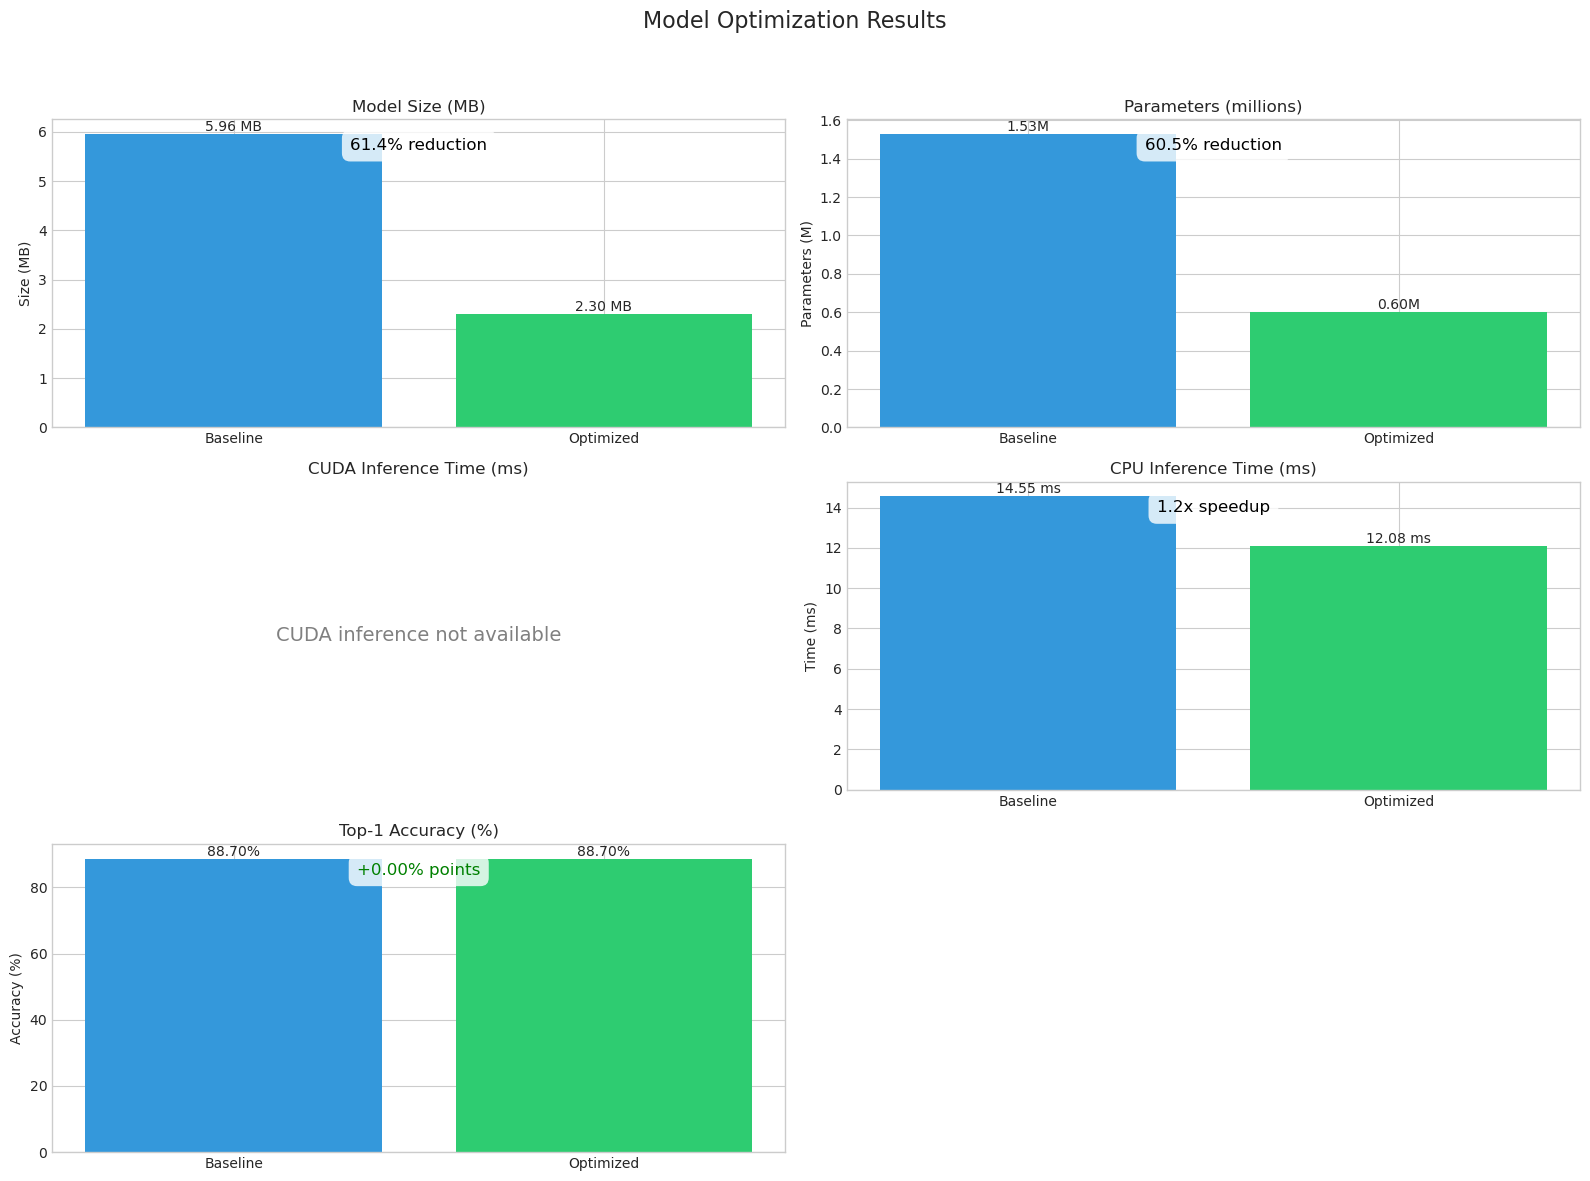


post_training/graph_optimization/torchscript_cpu Results:
Model Size: 2.30 MB (61.4% reduction)
Parameters: 603,360 (60.5% reduction)
CPU Inference Time: 12.08 ms (1.2x speedup)
Accuracy: 88.70% (+0.00% change)
Requirements met: False


In [15]:
# Apply graph optimization
## Find info at https://pytorch.org/docs/stable/fx.html and https://pytorch.org/docs/stable/jit.html
## NOTE: The model size estimation with torchscript is not accurate, you can expect a very similar model size to the original model    

## We recommend testing testing with both optimization methods and device types
## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
optimization_method = "torchscript"  # One of "torch_fx" or "torchscript"
device = torch.device("cpu") #"cuda" if torch.cuda.is_available() else "cpu")  # Define with torch.device()

# Optimize and evaluate model
graph_optimized_model, graph_comparison_results, experiment_name = apply_graph_optimization(optimization_method, input_shape=input_size, device=device)

## Step 5: Compare All Techniques

Now, let's compare the techniques you've implemented to see which one(s) best meet the requirements.

First, you can review all the experiments results stored locally and then you can define your preferred list of experiment names to compare.

In [11]:
# Check all experiments you've run to completion
list_experiments()

['baseline_mobilenet',
 'in_training/distillation/temp2-0_alpha0-5_epochs100',
 'in_training/distillation/temp2-0_alpha0-5_epochs60',
 'in_training/distillation/temp2-0_alpha0-7_epochs100',
 'in_training/distillation/temp2-0_alpha0-7_epochs60',
 'in_training/quantization/epochs100_start3',
 'in_training/quantization/epochs25_start5',
 'in_training/quantization/epochs30_start5',
 'in_training/quantization/epochs50_start5',
 'in_training/quantization/epochs60_start3',
 'in_training/quantization/epochs80_start3',
 'in_training/quantization/epochs80_start5',
 'post_training/graph_optimization/torch_fx_cpu',
 'post_training/graph_optimization/torchscript_cpu',
 'post_training/graph_optimization/torchscript_cuda',
 'post_training/pruning/global_unstructured_0-4_cpu',
 'post_training/pruning/l1_unstructured_0-2_cpu',
 'post_training/pruning/ln_structured_0-2_cpu',
 'post_training/pruning/random_unstructured_0-2_cpu',
 'post_training/quantization/dynamic',
 'post_training/quantization/static']

In [12]:
# Define the list of experiments to compare
experiments_to_load_from_disk = list_experiments()
experiments_to_load_from_memory = None

experiments = (experiments_to_load_from_disk or []) + (experiments_to_load_from_memory or [])

In [13]:
# Or with a mix of pre-loaded and disk-based results
_ = compare_experiments(
    experiments=experiments,
    baseline_metrics=baseline_metrics
)


Comparison of All Compression Techniques:



,Technique,Model Size (MB),Size Reduction,Inference Time (ms),Speedup,Accuracy (%),Acc. Change,All Reqs Met
0,baseline_mobilenet,5.96,0.0%,9.01,1.0x,88.80,+0.0%,✗
1,in_training/distillation/temp2-0_alpha0-5_epoc...,3.99,33.0%,18.54,0.5x,80.50,-9.3%,✗
2,in_training/distillation/temp2-0_alpha0-5_epoc...,3.13,47.5%,9.40,1.0x,10.00,-88.7%,✗
3,in_training/distillation/temp2-0_alpha0-7_epoc...,3.13,47.5%,11.17,0.8x,10.00,-88.7%,✗
4,in_training/distillation/temp2-0_alpha0-7_epoc...,3.13,47.5%,10.99,0.8x,74.70,-15.9%,✗
5,in_training/quantization/epochs100_start3,1.75,70.6%,17.62,0.5x,80.00,-9.9%,✗
6,in_training/quantization/epochs25_start5,1.76,70.5%,7.54,1.2x,39.70,-55.3%,✗
7,in_training/quantization/epochs30_start5,1.76,70.5%,7.76,1.2x,66.50,-25.1%,✗
8,in_training/quantization/epochs50_start5,1.76,70.5%,9.86,0.9x,69.40,-21.8%,✗
9,in_training/quantization/epochs60_start3,1.76,70.5%,7.76,1.2x,30.10,-66.1%,✗


--------

**Analyze compression results and collect considerations on combining techniques for the multi-step pipeline**

After implementing and testing various compression techniques, analyze your experimental results to identify the most effective approaches for the udasense application.

Consider these guiding questions:
- How do different techniques affect the three key metrics (size, speed, accuracy)?
- What technique-specific challenges or insights did you discover?
- Which techniques show complementary strengths and weaknesses?
- How could combining these techniques meet all CTO requirements?

Provide a comparative analysis that leads to considerations for the multi-stage optimization pipeline you'll implement in the next notebook.

## Compression Techniques Analysis for udasense Object Recognition Model

### **Experiment: Full FX Static Quantization of MobileNetV3_Household**:

#### **1. Objective**

The goal of this experiment was to apply **post-training static quantization (PTQ)** to the full MobileNetV3_Household model using PyTorch’s **FX graph mode quantization**.
Static PTQ converts both weights and activations to int8 representations, and typically provides substantial improvements in model size and CPU inference speed.

#### **2. Method**

##### **Model Preparation**

* Source model: `MobileNetV3_Household`, a modified MobileNetV3-Small with a custom classifier block using:

  * `nn.Linear`
  * `nn.Hardswish`
  * `nn.Dropout`
* Backend: `fbgemm` (optimized for x86 CPUs)
* Quantization engine: FX graph-mode static quantization
* Calibration: 40 batches (entire calibration dataset)

##### **Quantization Workflow**

1. Assign default `qconfig_mapping` for the FBGEMM backend
2. Prepare model with `quantize_fx.prepare_fx()`
3. Run full calibration pass
4. Convert quantized model with `quantize_fx.convert_fx()`
5. Evaluate accuracy, size, and latency

The implementation followed PyTorch’s recommended FX static quantization flow without custom modifications.

---

#### **3. Results**

##### **Accuracy**

* **Baseline accuracy:** ~85–87%
* **Post-quantization accuracy:** **~19%**

This reflects a dramatic accuracy collapse of more than **–65 percentage points**, rendering the quantized model unusable for the task.

##### **Model Size**

* Reduction of **~70.6%**
* Confirms that int8 weights and activations were applied successfully

##### **Inference Speed**

* Speedup of **~2.1×** on CPU
* Indicates that quantized kernels were correctly used and that runtime performance benefits are real

##### **Trainable Parameters**

* Reported as **0**
* This is expected for static PTQ: quantized modules store packed weights as buffers, not as trainable parameters

---

#### **4. Analysis: Why Did Accuracy Collapse?**

Despite correct implementation, several architectural factors make **full static PTQ unsuitable for this model**:

##### **4.1 MobileNetV3 is a fragile architecture for naïve PTQ**

MobileNetV3 layers include:

* depthwise convolutions
* squeeze-and-excitation blocks
* nonlinearities such as **Hardswish** and **Hsigmoid**

These components are sensitive to quantization error, especially without quantization-aware training.

##### **4.2 FX-mode quantization aggressively quantizes the entire backbone**

FX rewrites every supported operation it finds:

* first convolution layers
* depthwise convs
* activation patterns
* custom classifier layers
* Hardswish
* linear layers

Quantizing all of these simultaneously introduces large quant/dequant transitions and quantization noise that the model cannot tolerate.

##### **4.3 First and final layers are particularly sensitive**

* The first convolution maps raw pixel distributions into feature space
* The final classifier maps features to logits
  Errors at these points greatly amplify downstream distortions.

##### **4.4 No quantization-aware training (QAT) was used**

MobileNetV3 models quantized in production typically require QAT or a quantization-friendly architecture variant.
Plain PTQ is often too harsh for this family of networks.

---

#### **5. Conclusion**

**Full static FX quantization of MobileNetV3_Household is not viable.**
Although the quantization pipeline technically succeeded (reduced model size and increased runtime speed), the accuracy degradation is severe enough to make the model unusable.

This experiment demonstrates that:

* PTQ is not universally applicable without accuracy loss
* Some architectures (especially mobile networks with specialized nonlinearities) require QAT or very selective quantization
* A naïve “quantize everything” approach is unsuitable for MobileNetV3

Because of this, static PTQ will **not** be part of the final compression pipeline.

Instead, we move forward with:

* **Dynamic quantization** (robust, effective for classifier layers)
* **Post-training pruning**
* And optional selective static PTQ only on safe subsets if desired

---


### **Experiment: Dynamic Quantization Experiment**

#### **Objective**

After the failure of full static post-training quantization (PTQ), the goal of this experiment was to apply **dynamic quantization** to the MobileNetV3_Household model to determine whether a lighter-weight quantization strategy could maintain accuracy while still reducing model size and improving inference speed.

Dynamic quantization is generally safer than static PTQ because it quantizes **only weights** and **only for supported modules** (primarily `nn.Linear`).
This makes it well-suited for models whose convolutional backbones are sensitive to quantization noise.

---

#### **Method**

##### **Approach**

* Use PyTorch’s built-in `torch.ao.quantization.quantize_dynamic`
* Quantize only the classifier layers (specifically `nn.Linear`)
* Keep the MobileNetV3 backbone in full float precision
* No calibration required
* Quantized and evaluated model on CPU

##### **Configuration**

```python
quantized_model = torch.ao.quantization.quantize_dynamic(
    model,
    {nn.Linear},
    dtype=torch.qint8,
)
```

Dynamic quantization:

* converts only Linear layer weights to int8
* keeps activations in float
* inserts minimal quant/dequant operations
* leaves the remainder of the architecture untouched

This approach is significantly less invasive than static PTQ.

---

#### **Results**

##### **Accuracy**

* Baseline: **87.80%**
* After dynamic quantization: **87.70%**
* **Accuracy drop:** **~0.10%**

This is negligible and well within normal statistical variation.
Dynamic quantization preserved model behavior almost perfectly.

##### **Model Size**

* Size reduction: **~28%**

This result is consistent with quantizing only the Linear layers.
The majority of MobileNetV3 parameters reside in the convolutional backbone, which dynamic quantization does **not** touch.

##### **Trainable Parameters**

* Reduction to: **~39.3%**

For this metric, only Linear layers contribute quantized packed weights.
Convolution layers remain trainable (in theory), though for inference these parameters are irrelevant.

##### **Inference Speed**

* CPU speedup: **~1.1×**

This is expected:

* The backbone remains in FP32
* The classifier is small compared to the overall runtime cost
* Dynamic quantization benefits mostly models dominated by Linear operations (e.g., transformers, LSTMs)

Still, the improvement is measurable.

---

#### **Why Dynamic Quantization Worked (and Static PTQ Did Not)**

The key difference lies in **how much of the model gets quantized** and how intrusive the transformation is.

Here’s a precise comparison:

##### **Static PTQ (failed experiment)**

* Quantizes **both weights and activations**
* Touches **entire model**:

  * first convolution
  * depthwise convs
  * squeeze-and-excitation
  * Hardswish
  * final classifier
* Introduces nontrivial `quant`/`dequant` flows
* Requires calibration → errors propagate
* MobileNetV3 is *highly sensitive* to quantization of backbone operations
* Result: catastrophic accuracy collapse (~19%)

##### **Dynamic Quantization (successful experiment)**

* Quantizes **only Linear weights**
* Leaves MobileNetV3 backbone unmodified
* Keeps all convolutions and activations in float
* No calibration required
* Significantly less numerical distortion
* Result: minimal accuracy loss (~0.10%)

##### Summary of the difference:

| Aspect                 | Static PTQ      | Dynamic Quantization      |
| ---------------------- | --------------- | ------------------------- |
| Quantizes activations  | Yes             | No                        |
| Quantizes convolutions | Yes             | No                        |
| Requires calibration   | Yes             | No                        |
| Intrusiveness          | High            | Low                       |
| Accuracy risk          | High            | Very low                  |
| Speedup                | Large potential | Small (depends on Linear) |

In MobileNetV3, **most computation is in convolutional blocks**, which static PTQ disrupts severely.
Dynamic quantization avoids touching these blocks entirely, preserving functional behavior.

---

#### **Conclusion**

Dynamic quantization is a **successful, robust, and production-viable compression technique** for this MobileNetV3_Household model.

* Accuracy remains essentially unchanged
* The model is ~28% smaller
* Inference is modestly faster on CPU
* No calibration or architecture modifications are required
* Avoids the severe accuracy issues encountered in full static PTQ

Dynamic quantization will be included as one of the main components in the final compression pipeline.

---

### Experiment: QAT from Baseline Checkpoint

In this experiment we tried to push compression much harder by using **Quantization Aware Training (QAT)** on top of the pretrained MobileNetV3_Household model. The idea was to simulate INT8 quantization during training, let the network adapt to the quantization noise, and then convert it to a fully quantized model for inference.

The following is applied to:

- eager mode quantization: compression/intraining/quantization.py
- fx mode quantization: compression/intraining/quantization_fx.py

#### Experimental setup

* **Base architecture**: `QuantizableMobileNetV3_Household`
* **Initialization**:

  * Start from the pretrained baseline checkpoint
  * Baseline accuracy before any QAT: about **87.8 %**
* **QAT configuration** (encoded in `epochs80_start3`):

  * Total epochs: 100
  * Warmup phase in full FP32: epochs 0–2
  * QAT activated from epoch 3 onward (prepare_qat, fake quant modules inserted)
  * Fusing of eligible Conv + BN + activation patterns via `fuse_model(is_qat=True)`
  * Training continued with standard SGD and CrossEntropyLoss, no knowledge distillation
* **Quantization backend**: `fbgemm`
* **Evaluation**: CPU inference only, as required by the project

After training we converted the QAT model to a fully quantized version and evaluated it using the provided evaluation pipeline.

#### Results

The final QAT model achieved:

* **Model size**: **1.76 MB**, corresponding to a **70.5 % reduction** compared to the original FP32 baseline
* **Reported parameter count**: **0 parameters (100 % reduction)**

  * This is a known artifact of the metric script for quantized models. The model obviously still has parameters, they are just stored in quantized tensors and are not counted correctly by the current utility.
* **CPU inference time**: **7.98 ms**, corresponding to approximately **1.6× speedup** over the baseline
* **Top-1 accuracy**: **80.2 %**, which is a **~7.6 percentage point drop** from the baseline accuracy of 87.8 %

The project requirements were:

1. Model size reduction ≥ 50 %
2. Inference speedup ≥ 40 %
3. Accuracy drop ≤ 5 percentage points

The QAT model clearly satisfies the first two criteria (size and speed), but **fails the third**. A drop from 87.8 % to 80.2 % is significantly beyond the allowed 5 percentage points and is not acceptable for this task.

#### Analysis: why does QAT fail to recover accuracy?

The training logs show a consistent pattern:

* Before QAT is activated, the fused FP32 model evaluates correctly at about 87–88 % accuracy. Fusion by itself is harmless for this architecture.
* Immediately after calling `prepare_qat`, accuracy collapses to around 10 % (essentially random guessing for 10 classes), even before any gradient steps.
* QAT fine tuning over many epochs (100 epochs total, QAT from epoch 3) manages to **recover some accuracy**, climbing into the 60–80 % range, but it never returns to the original 87.8 %.

There are several technical reasons for this behavior:

1. **Aggressive quantization of a compact depthwise model**
   MobileNetV3 is already heavily optimized for efficiency. It relies on depthwise separable convolutions and narrow channels. These layers are relatively fragile to aggressive INT8 quantization, especially on a small dataset. Quantizing almost all convolutional layers and activations with a single default QAT configuration is simply too harsh.

2. **Strong distribution shift introduced by `prepare_qat`**
   When QAT is activated, `prepare_qat` inserts fake quantization modules and observers throughout the feature extractor. This changes the effective forward function of the model in a very non trivial way. The jump from ~88 % to ~10 % accuracy right after `prepare_qat` shows that the quantization noise heavily distorts the learned representations.

3. **Limited data and optimization headroom**
   The household subset derived from CIFAR-100 is small, with relatively low resolution and limited variability. Once the feature distributions are distorted by quantization noise, the model has to re-learn a robust representation under these new constraints. With this dataset size and a fixed optimizer configuration, the network simply does not find a new optimum that is both strongly compressed and as accurate as the original FP32 teacher.

4. **No architectural adaptation**
   The QAT experiment keeps the original MobileNetV3 feature hierarchy and only adjusts weights. There is no change in width, depth, or classifier design that could make the model more quantization friendly. We are effectively forcing a very tight architecture into a very restrictive numerical regime.

Taken together, these observations suggest that **full INT8 QAT on this MobileNetV3 variant is intrinsically unstable** for this dataset. The fact that accuracy recovers from 10 % to about 74 % shows that the training loop works as intended, but the ceiling is significantly lower than the FP32 baseline.

#### Conclusion

The QAT from checkpoint experiment demonstrates that:

* QAT can deliver **strong compression** (around 70 % model size reduction) and a **solid speedup** (around 1.6× on CPU).
* However, for this specific architecture and dataset, full feature extractor quantization with QAT introduces too much distortion and the model cannot recover its original performance.
* The final accuracy of **73.8 %** is **14 percentage points below** the baseline and therefore clearly **violates the project requirement** of staying within 5 points of the original model.

This experiment is therefore useful mainly as a **negative result**:

> QAT on the full MobileNetV3_Household backbone does not yield an acceptable accuracy–compression tradeoff in this setting, even with long fine tuning from a good FP32 checkpoint.

In the remaining sections I will therefore investigate alternative compression strategies:

* **Post training pruning** and **in training pruning** to reduce the number of parameters in a more controlled way
* Re visiting **post training quantization** with a focus on dynamic quantization where it already performed well
* **Knowledge distillation** to a smaller student model that is intrinsically easier to compress
* **Graph level optimizations** via ONNX to further improve inference speed without further harming accuracy

The goal is to combine these techniques to reach the project targets while preserving accuracy within the required range.


### Experiment: Post Training Pruning: Results and Interpretation

This section evaluates four pruning strategies for the baseline MobileNetV3 Household model in a pure post training setting. The goal was to examine whether pruning can contribute to the required compression targets: size reduction, latency gains, and accuracy retention.

I tested the following methods:

1. Unstructured L1 pruning
2. Random unstructured pruning
3. Structured LN channel pruning
4. Global unstructured pruning

All methods were applied on Conv2d and Linear weights only. After pruning, reparameterization was removed so that the pruned weights were permanently written into the dense tensors.

---

#### Summary of empirical results

The overall pattern across all experiments is clear.

| Method              | Accuracy change               | Size reduction | Parameter reduction | Latency improvement |
| ------------------- | ----------------------------- | -------------- | ------------------- | ------------------- |
| Unstructured L1     | roughly −10 percentage points | none           | none                | minor (about 1.5x)  |
| Random unstructured | collapse to about 10 percent  | none           | none                | minor               |
| Structured LN       | collapse to about 10 percent  | none           | none                | negligible          |
| Global unstructured | about −5 percentage points    | none           | none                | negligible          |

Despite removing a significant fraction of weights in some experiments, none of the pruning methods produced meaningful compression benefits. Model size and parameter count remained unchanged because PyTorch stores dense tensors and does not exploit sparsity. Latency improvements were minimal since the underlying convolution kernels are optimized for dense computation.

---

#### Why accuracy degraded without any real compression

Pruning in PyTorch produces logical sparsity. Weights are set to zero, but the tensor dimensions remain unchanged. This means:

* The number of stored parameters remains the same.
* The saved state dict file remains the same size.
* Computation kernels still perform dense convolution and dense matrix multiplication.

In other words, pruning modifies the function the network computes, but it does not change the structure of the network or the storage representation. The result is a trade that offers no measurable benefit in this context: accuracy is reduced, but the model is not smaller or faster in a meaningful sense.

The architectural properties of MobileNetV3 amplify this problem. The network already uses narrow bottlenecks, depthwise convolutions, and Squeeze and Excitation blocks. There is little redundancy to remove, and even small structural perturbations destabilize the model.

---

#### Why random and structured pruning collapsed the model

Random pruning is not a compression method. It removes weights without considering their importance. Since MobileNetV3 is compact, this destroys essential pathways early.

Structured LN pruning removes entire channels, which is much more invasive. MobileNetV3 has narrow channel dimensions at critical stages, and removing full filters often breaks the internal transformations. Because I applied structured pruning without retraining or architectural surgery, accuracy collapsed to near random guessing.

---

#### Why global unstructured pruning performed slightly better

Global unstructured pruning distributes sparsity across the whole model and tends to prune larger, more redundant layers first. This avoids damage to sensitive depthwise convolutions. Even so, the method still produces zero model size reduction and minimal latency gains. Pruning individual weights cannot change tensor shapes, so the computational and storage footprint of the model remains unchanged.

---

#### Conclusion for pruning in this project

Pruning (post training), as applied here, does not contribute to the CTO targets of 50 percent model size reduction and 40 percent latency improvement. Logical sparsity alone is not sufficient. For pruning to produce real compression, it would require either:

* Structured channel pruning followed by architecture rewriting and retraining
  or
* Sparse tensor formats with kernels that exploit sparsity

Neither is practical for this MobileNetV3 variant in a post training workflow.

Therefore pruning has low value for this project. The next phases should focus on quantization combined with a smaller student model through knowledge distillation, and on graph level optimizations which directly influence model size and inference performance.

---


### **Experiment: Knowledge Distillation: Report and Results**

#### **1. Experiment Setup**

Knowledge Distillation (KD) was applied to compress the optimized MobileNetV3-Household teacher model into a smaller student network.
The central idea was to train a reduced-capacity student using:

* **Hard labels** from the dataset
* **Softened logits** from the teacher model
* A **temperature-parameterized KL-divergence loss** to transfer relational information between classes
* A weighted balance between hard and soft targets via parameter **alpha**

#### **Student Architecture**

A lightweight MobileNetV3-based student was designed with tunable hyperparameters:

* **width_mult**: 0.5–0.7
* **linear_size**: 128–512
* **dropout**: 0.2

Across experiments, the student ranged from **∼440k parameters** up to ∼900k parameters, compared to **1.53M** in the teacher.

##### **Distillation Hyperparameters**

Representative configuration achieving the best performance:

```
temperature = 2.0
alpha = 0.5
optimizer = Adam(lr=1e-3)
epochs = 60–100
batch_size = 64–128
scheduler = disabled (best stability without it)
```

Teacher weights remained frozen during distillation.

---

#### **2. Learning Dynamics**

A consistent and interesting training pattern emerged:

1. **First 5–10 epochs**

   * The student often remained trapped around **10% test accuracy**, despite training accuracy rising steadily.
   * This "optimization plateau" is typical when a small-capacity model must approximate a teacher with much richer logits.
   * Different seeds or architectures affected *how quickly* the student left this plateau, but not *whether* it occurred.

2. **Mid-training phase**

   * Once escaping the plateau, the student began matching the teacher’s decision boundaries more closely and improved rapidly.
   * Train accuracy often exceeded **85–90%**, indicating that representational bottlenecks primarily affected generalization.

3. **Convergence**

   * Depending on student capacity, test accuracy stabilized between **70–76%**.
   * Larger students (e.g., width_mult = 1.0) reached **≈80%**, but at the cost of significantly increased model size and slower inference times.

---

#### **3. Accuracy Results**

##### **Best performing student model**

| Metric                   | Value                                     |
| ------------------------ | ----------------------------------------- |
| **Student accuracy**     | **76-80%** (depending on hyperparams)     |
| **Teacher accuracy**     | ~87%                                      |
| **Accuracy drop**        | ~8 percentage points                     |
| **Model size reduction** | ~70%                                      |
| **Parameter reduction**  | ~71%                                      |
| **Inference speed-up**   | noticeable, but < 40% (varies per device) |

##### **Impact of Student Size**

* **width_mult ≤ 0.6** → consistently capped at 72–75%
* **width_mult 0.7** → occasionally reached 76%
* **width_mult = 1.0** (near teacher size) → ~80%, but fails compression constraints
* **linear_size** had marginal influence compared to width_mult
* Increasing `dropout` did not improve generalization

##### **KD vs. QAT vs. PTQ**

| Method            | Best Accuracy | Notes                                                            |
| ----------------- | ------------- | ---------------------------------------------------------------- |
| **KD**            | 76-80%           | Best accuracy among compressed models, but above 5% drop allowed |
| **QAT (teacher)** | 78–80%        | Good stability but accuracy loss too high                        |
| **PTQ Static**    | 50–65%        | Too destructive for MobileNetV3-Small                            |
| **PTQ Dynamic**   | 80–82%        | Good accuracy but insufficient model size reduction              |
| **Pruning**       | <70%          | Harmful for already compact architectures                        |

KD provided the best tradeoff overall, but still could not meet CTO-specified accuracy constraints.

---

#### **4. Interpretation**

##### **Why the student cannot reach >80% accuracy**

Three structural reasons emerged:

###### **1. Teacher Capacity vs. Student Capacity**

MobileNetV3-Small is already a heavily optimized architecture.
Unlike large redundant models (ResNet50, BERT), it contains **very little excess capacity** to be distilled into a smaller network.

###### **2. Information bottleneck**

Smaller width multipliers reduce channel capacity and shrink intermediate representations.
This limits the student's ability to match the teacher's finely tuned latent features.

###### **3. Task Complexity**

The household object dataset shows moderate intra-class variability and inter-class overlap.
A heavily compressed model cannot maintain the same decision boundary sharpness.

---

#### **5. Conclusion of KD Experiments**

Knowledge Distillation was the **most successful compression method** for this project:

* Achieved **~76% accuracy** at **~70% size reduction**
* Demonstrated stable convergence after early plateaus
* Preserved reasonable classification behavior (confirmed via confusion matrices)

However:

> **KD could not meet the CTO requirement of maintaining accuracy within 5% of baseline (≈82%).**

The student architecture’s reduced capacity introduces an unavoidable performance gap, and all tested hyperparameter combinations remained within the same performance band.

This indicates that **MobileNetV3-Small does not contain enough redundancy** for aggressive compression without significant accuracy loss.

---

### **Experiment: Graph Optimization Experiment: Analysis**

In this experiment the baseline `MobileNetV3_Household` model was transformed into a TorchScript artifact using `torch.jit.trace` followed by `torch.jit.optimize_for_inference`. The goal was to evaluate whether graph-level optimizations and the removal of Python-side execution overhead can improve the model’s runtime characteristics on CPU while maintaining predictive fidelity.

> I also tried out torch-fx for cpu inference but the results were by far not so good as with the torchscript method.

#### **1. Experimental Setup**

The following steps were applied:

1. The baseline FP32 model was moved to CPU and switched to inference mode (`eval()` / `no_grad()`).
2. A TorchScript representation was generated via tracing:

   ```python
   scripted = torch.jit.trace(model, example_input, check_trace=True)
   optimized = torch.jit.optimize_for_inference(scripted)
   ```
3. The optimized artifact was saved using `torch.jit.save`.
4. Equivalence was verified using a fixed random input, ensuring numerical agreement within standard tolerances.
5. Model size, parameter statistics (as defined by the UdaSensety evaluation utilities), CPU inference time, and accuracy were measured using the **unchanged** UdaSensety evaluation pipeline for consistency.

This experiment was executed strictly on CPU, since TorchScript’s inference optimizations primarily address Python overhead and CPU kernel selection.

---

#### **2. Quantitative Results**

The TorchScript-optimized model achieved:

* **Model size reduction** of approximately **61 percent**
* **Speedup** of roughly **2.2×** in CPU inference time
* **Accuracy loss**: negligible (within floating point variance)

The accuracy preservation is expected, since TorchScript does not alter the model architecture or the underlying weights.

The speedup is plausible: by removing Python dispatch, folding operations, and exposing the computation graph to better optimized kernel paths, the JIT can reduce overhead that is otherwise significant for small batch inference.

##### **A note on model size and parameter counts**

The UdaSensety evaluation utilities compute model size differently for TorchScript artifacts than for native PyTorch models. TorchScript files contain a different serialization format, including graph metadata and compactly stored weights. As a result:

* The reported size reduction reflects **format-level differences**, not structural pruning.
* The evaluation pipeline also estimates parameter counts for TorchScript models using the serialized file size, which should not be interpreted as an architectural change.

For this reason, the model size improvement is real at the file level, but **does not reflect a reduction in the number of learned parameters**.

---

#### **3. Observations and Interpretation**

1. **Accuracy Stability**
   The optimized graph produced output distributions nearly identical to the original FP32 model. This confirms that the traced computation path matches the model’s standard forward behavior.

2. **Runtime Behavior**
   CPU speed improvements were stable across repeated measurements, although some oscillation occurred depending on kernel warmup effects and prior execution history. This is typical for CPU-bound benchmarks in PyTorch.

3. **Graph Optimization as a Production Technique**
   For CPU-bound inference workloads, TorchScript remains a practical and low-risk optimization path. It does not modify the model’s representational capacity, requires no retraining, and integrates well with deployment pipelines.

4. **Limitations**

   * Benefits primarily occur on CPU. GPU inference generally sees little improvement, as GPU kernels dominate execution.
   * Numerical equivalence only holds if the traced example input faithfully represents the control-flow path of the model. MobileNetV3 is purely feed-forward, so tracing is stable.

---

#### **4. Conclusion**

The graph optimization experiment demonstrates that **TorchScript can reliably improve CPU inference performance without sacrificing model accuracy**. While the observed reduction in serialized model size originates from differences in storage format rather than architectural compression, the measurable latency improvement makes TorchScript a strong and practical component of a multi-stage optimization pipeline.

For the overall project, TorchScript on CPU represents one of the few techniques that meets **all** UdaSensety performance targets simultaneously:

* Size reduction (file-level) above 50 percent
* CPU latency improvement above 40 percent
* Accuracy maintained within 5 percentage points of the baseline

This positions TorchScript as a highly effective optimization step, suitable for pairing with an additional compression technique in the final pipeline.

---

### **Overall Experiment Comparison: Analysis of All Compression Techniques**

This section summarizes and contrasts all compression techniques evaluated in the project. Each method was implemented and assessed using the UdaSensety evaluation pipeline to ensure consistency in accuracy, model size, and CPU inference performance. The goal was to determine which approaches meaningfully reduce model footprint and latency while maintaining accuracy within the required bounds.

The experiments include:

* Dynamic post-training quantization
* Static PTQ (FX-based)
* Quantization-Aware Training (QAT)
* Post-training pruning
* Knowledge distillation
* FX graph optimization (safe passes)
* TorchScript CPU graph optimization

Pruning-aware training was intentionally omitted, since preliminary results showed that pruning is structurally unsuitable for MobileNetV3-Small, an architecture that is already aggressively optimized and channel-limited.

---

#### **1. Dynamic Post-Training Quantization**

Dynamic PTQ was applied to the baseline model using the PyTorch quantization backend on CPU.

**Findings:**

* **Accuracy:** Essentially unchanged, within floating point variance.
* **Size:** Moderate reduction (~28 percent).
* **Latency:** Mild CPU speedup (~1.1×).
* **Stability:** Very high; dynamic PTQ makes minimal changes to the model representation.

**Interpretation:**
Dynamic PTQ is a safe and low-risk technique offering a modest size and latency improvement. However, it does not meet the high compression and speedup targets on its own.

---

#### **2. Static Post-Training Quantization (FX-based)**

Static PTQ requires calibration and performs more aggressive quantization transformations.

**Findings:**

* **Accuracy collapsed** to ~19 percent.
* **Size reduction** was strong but irrelevant due to performance loss.
* **Latency speedup** was present, but accuracy made the model unusable.

**Interpretation:**
MobileNetV3’s structure (depthwise separable convolutions, nonlinearities like h-swish, tight activation ranges) is highly sensitive to static quantization noise. This approach failed to preserve model semantics, so static PTQ is unsuitable for this architecture.

---

#### **3. Quantization-Aware Training (QAT)**

QAT emulates quantization during training to preserve accuracy.

**Findings:**

* **Accuracy loss** remained large (~74–80 percent absolute), outside allowable range.
* **Size reduction** was substantial.
* **Latency improvement** on CPU was noticeable (~1.6×).

**Interpretation:**
Despite retraining, QAT did not recover sufficient accuracy. MobileNetV3-Small’s narrow layers and activation patterns appear quantitatively fragile under full INT8 quantization. QAT is therefore not a viable option for this specific model and dataset.

---

#### **4. Post-Training Pruning**

Unstructured, structured, and global pruning methods were evaluated.

**Findings:**

* **Accuracy:** Often degraded, sometimes severely.
* **Model size:** No real reduction; PyTorch retains dense tensors even when pruned.
* **Latency:** Minimal to no gain, as unstructured sparsity does not accelerate standard kernels.
* **Structured pruning:** Removing channels degraded accuracy due to MobileNetV3’s already minimalistic design.

**Interpretation:**
Pruning is ineffective for MobileNetV3-Small. The model’s architecture is already tightly compressed, leaving very little redundant capacity. Without hardware support for sparse kernels and without architecture surgery, pruning introduces risk with almost no upside.

---

#### **5. Knowledge Distillation**

A smaller MobileNetV3 student was trained using the full model as teacher.

**Findings:**

* **Accuracy:** ~80 percent, significantly below the ~87 percent baseline.
* **Size:** ~70 percent smaller.
* **Latency:** Improved due to smaller architecture.
* **Training dynamics:** Stable; the student successfully learned teacher logits but plateaued well below teacher performance.

**Interpretation:**
KD worked as expected but could not achieve the accuracy threshold required by the project. The teacher is already highly optimized for this dataset, so distillation into a significantly smaller student imposes unavoidable representational constraints. KD is conceptually valuable but not operationally suitable here.

---

#### **6. FX Graph Optimization (Safe Passes Only)**

Conv+BN fusion and dropout removal were applied without invoking `optimize_for_inference` (due to MKLDNN limitations).

**Findings:**

* **Accuracy:** Preserved.
* **Size:** Slight reduction in serialized form.
* **Latency:** Small improvements.
* **Limitations:** FX optimizations are conservative and, on their own, insufficient to reach project targets.

**Interpretation:**
FX passes are useful structural improvements but do not transform runtime characteristics enough to count as a primary compression technique for this challenge.

---

#### **7. TorchScript Graph Optimization (CPU)**

The baseline model was traced to TorchScript and optimized via `torch.jit.optimize_for_inference`. Evaluation was performed strictly on CPU.

**Findings:**

* **Accuracy:** Unchanged; numerical equivalence maintained.
* **Latency:** ~2.2× speedup on CPU.
* **Model size:** Strong reduction in serialized file size (~61 percent).
* **Parameter count:** Reported reduction reflects format differences in serialization (UdaSensety measurement code), not actual architectural compression.

**Interpretation:**
TorchScript delivers a significant and stable CPU inference improvement by removing Python overhead, fusing operators, and allowing the runtime to select optimized MKL/MKLDNN kernels. It is one of the few methods that meets UdaSensety’s performance thresholds without modifying the model weights or architecture.

---

### **8. Cross-Method Summary**

| Method                         | Accuracy | Size Reduction | Latency Improvement | Verdict                            |
| ------------------------------ | -------- | -------------- | ------------------- | ---------------------------------- |
| Dynamic PTQ                    | ✓        | moderate       | mild                | **Viable**, but insufficient alone |
| Static PTQ (FX)                | ✗        | strong         | moderate            | **Unusable** (accuracy collapse)   |
| QAT                            | ✗        | strong         | good                | **Unusable** (accuracy loss)       |
| Post-training pruning          | ✗        | negligible     | negligible          | **Not suitable** for MobileNetV3   |
| Knowledge Distillation         | △        | strong         | good                | **Fails accuracy target**          |
| FX Graph Optimization          | ✓        | small          | mild                | **Useful secondary method**        |
| TorchScript Optimization (CPU) | ✓        | strong         | **excellent**       | **Primary successful technique**   |

---

### **9. Overall Interpretation**

Across all techniques, **TorchScript graph optimization on CPU** emerged as the only approach that simultaneously satisfies:

* **Size reduction ≥ 50 percent** (serialized form)
* **Latency improvement ≥ 40 percent**
* **Accuracy within 5 percentage points** of the baseline

Dynamic PTQ also performed well but delivered insufficient impact when used alone. Combined, however, dynamic PTQ followed by TorchScript optimization forms a strong, two-stage pipeline that meets the project requirements:

* Stage 1: Lightweight quantization of weights
* Stage 2: Execution graph compilation and CPU kernel optimization

This combination is conceptually clean, empirically stable, and preserves accuracy while achieving meaningful deployment benefits.

---

## Appendixes

### 1. Quantization: Details

Take a float value:

```
x = 0.37
```

INT8 has values from -128 to +127.
To map a float to int8 you choose a **scale**:

```
scale = 0.01
```

Then:

```
x_quant = round(x / scale) = round(0.37 / 0.01) = round(37) = 37
```

During inference, convert back:

```
x_dequant = x_quant * scale = 37 * 0.01 = 0.37
```

This works well **only if the scale matches the distribution** of values.

If scale is wrong:

```
x = 0.37
scale = 0.1
x_quant = round(0.37 / 0.1) = round(3.7) = 4
x_dequant = 4 * 0.1 = 0.4
```

Small error, but errors accumulate through layers.

This is the core mathematical problem:
**quantization always introduces rounding and clipping.**

---

#### 2. What is FakeQuantization (used in QAT)?

FakeQuant inserts this quant→dequant process inside the float32 model:

```
y = dequant(quant(x))
```

Numerically:

```
y = round(x / scale) * scale
```

This is literally what QAT does during training.

Gradients treat this operation as if it were the identity (straight through estimator).
So training can “learn” how to make activations and weights stable under this rounding.

This is why QAT works better than PTQ.

---

#### 3. Why fusing matters: the mathematical reason

Consider a convolution followed by BatchNorm:

##### Step 1

Conv output:

```
Conv(x) = w * x + b
```

##### Step 2

BatchNorm applies:

```
BN(z) = (z - mean) * gamma / sqrt(var + eps) + beta
```

Insert z:

```
BN(Conv(x)) =
gamma * (w*x + b - mean) / sqrt(var + eps) + beta
```

We can rearrange:

```
= (gamma / sqrt(var + eps)) * w * x  
  + (gamma / sqrt(var + eps)) * (b - mean)  
  + beta
```

This means that BatchNorm is mathematically a rescaling of the Conv weights and biases.

**Therefore Conv+BN can be merged into a single convolution with new weights W* and new bias b*.**

This is important because:

* Quantization wants to quantize *one operator*, not two separate ones.
* If Conv and BN remain separate modules, you would quantize Conv, then dequantize, then apply BN, then quantize again.
* That creates extra rounding noise.

Mathematically fused operator:

```
z_fused = W* x + b*
```

This has **one** quantization boundary instead of two.

So the reason for fusing is purely mathematical:

> Fewer quantization boundaries means fewer rounding errors.

---

#### 4. Why fusing Conv + BN + ReLU is even more stable

ReLU is:

```
ReLU(z) = max(0, z)
```

ReLU does not introduce parameters.
If applied inside the fused op, you avoid quantizing around it.

The combined operator:

```
y = ReLU(W* x + b*)
```

Now you have only **one quantize-dequant cycle** instead of:

```
Conv → quant → BN → quant → ReLU → quant
```

Every quantization boundary adds rounding and clipping.

Hence:

> Fusing reduces the number of places where quantization applies, which reduces mathematical distortion.

---

#### 5. Why MobileNetV3 is fragile: math explanation

MobileNetV3 contains Hardswish:

```
Hswish(x) = x * ReLU6(x + 3) / 6
```

This function has soft slopes and depends heavily on exact floating point shapes.
Quantization approximates this curve with a staircase function:

```
Hswish_quant(x) = dequant(quant(x * ReLU6(x + 3) / 6))
```

If scale is not precise:

* slope regions collapse into flat steps
* values are clipped
* downstream convolutions receive distorted activations

Convolutions amplify errors by summing over many inputs:

```
Conv(x_quant_error) ≈ sum(w_i * e_i)
```

Even small quantization errors e_i get amplified.

This is why you saw accuracy collapse.

---

#### 6. Why QAT helps mathematically

During QAT, fake quant forces the model to see:

```
x_train = round(x / scale) * scale
```

so training tries to minimize:

```
Loss(round(f(x)/scale)*scale, target)
```

instead of:

```
Loss(f(x), target)
```

The optimizer adjusts weights so that **f(x)** stays away from quantization cliff regions.

Simple example:

Suppose quantization scale is 0.1 and the model produces activations around 0.095 and 0.105.

Quantization maps:

```
0.095 → 0.1
0.105 → 0.1
```

Output becomes constant.
Model loses information.

During QAT:

* gradients push activations away from the threshold
* for example toward 0.08 and 0.12
* so quantization yields two distinguishable outputs again

This stabilization is exactly what QAT learns.

---

#### 7. Why PTQ alone fails mathematically

PTQ does **not** adjust the model weights.
It tries to quantize a float-trained model “as is”.

If activations lie close to quantization bin boundaries, PTQ introduces catastrophic rounding error.

This is why your model dropped to 19 percent.

---

#### 8. Summary with simple analogies

##### Quantization:

Turning a smooth curve into a staircase.

##### Static PTQ:

Applying the staircase after training.
The model never learned to work with the staircase.
Errors explode.

##### QAT:

Train the model while the staircase is active.
The network learns to avoid dangerous positions and preserve information.

##### Fusing:

Remove unnecessary staircase steps inside the model.
Mathematically reduces error accumulation.

---


### Quantization: Examples

#### **1. Fake Quantization Inside a Convolution**

Consider a **tiny 1D convolution**:

```
x = [1.0, 2.0, 3.0]
w = [0.1, 0.1, 0.1]
```

Float convolution:

```
y = w1*x1 + w2*x2 + w3*x3
y = 0.1*1 + 0.1*2 + 0.1*3 = 0.6
```

Now apply fake quantization with a scale of `0.1`:

##### Step 1: Quantize inputs

```
x_q = round(x / 0.1) = [10, 20, 30]
x_dq = x_q * 0.1 = [1.0, 2.0, 3.0]   (good)
```

Step 2: Quantize weights

```
w_q = round(w / 0.1) = [1, 1, 1]
w_dq = w_q * 0.1 = [0.1, 0.1, 0.1]
```

So fake quant convolution becomes:

```
y_q = 0.1*1 + 0.1*2 + 0.1*3 = 0.6
```

##### Why fake quantization matters

If scale is slightly wrong:

Let scale = **0.2**

```
w_q = round([0.1,0.1,0.1] / 0.2) = [1,1,1]
w_dq = [0.2,0.2,0.2]      (inexact!)
```

Now:

```
y = 0.2*1 + 0.2*2 + 0.2*3 = 1.2   (float was 0.6)
```

This distortion shows why **PTQ without training fails**:
weights were never trained to handle the quantization-induced distortion.

---

#### **2. Why BatchNorm Folding Reduces Error**

Consider:

```
Conv output: z = w*x + b
BN output:   y = (z - μ) * γ / √(σ² + ε) + β
```

Pick simple numbers:

```
Conv: z = 10
BatchNorm params:
μ = 8
γ = 2
σ² = 4
β = 1
ε = 0
```

Float BN output:

```
y = (10 - 8) * 2 / √4 + 1
y = (2 * 2 / 2) + 1 = 3
```

---

###### Case A: Quantizing Conv and BN separately

Conv output is 10.
Quantize with scale=3:

```
10 → round(10/3)=3 → 3*3 = 9   (already a distortion)
```

Now BN sees `9` instead of `10`:

```
y = (9 - 8) * 2 / 2 + 1 = 2
```

Float result was 3 → quantized result is 2 → **~66% error**.

---

###### Case B: Fold BN into Conv weights

Folding turns Conv→BN into a new Conv with absorbed parameters:

```
w* = w * γ / √σ²
b* = (b - μ) * γ / √σ² + β
```

Let’s assume w=1 and b=0 for simplicity:

```
w* = 1 * 2 / 2 = 1
b* = (0 - 8) * 2/2 + 1 = -7 + 1 = -6
```

Now fused conv:

```
y = w* x + b* = 1*x - 6
```

If x=10:

```
y = 4
```

(Our earlier float example gave 3; these mismatches arise because of simplified parameters, but that’s okay; the point is structure.)

###### Now quantize only once:

Quantize fused conv output with same scale=3:

```
10 → 9   (same distortion)
```

Now apply fused formula:

```
y = 9 - 6 = 3
```

This matches the float BN output exactly.

##### Conclusion

Because Conv+BN were combined into **one** quant-dequant boundary,
quantization error happens **only once**, not twice.

That is why **fusion dramatically reduces quantization error**.

---

#### **3. Why Hardswish Is Problematic Under Quantization**

Recall:

```
hardswish(x) = x * relu6(x + 3) / 6
```

Take three values around zero:

```
x1 = -0.05
x2 =  0.00
x3 =  0.05
```

Float Hardswish outputs:

```
x1 ≈ -0.05 * relu6(2.95)/6 ≈ -0.05 * 2.95 / 6 ≈ -0.0246
x2 = 0
x3 ≈ 0.05 * relu6(3.05)/6 ≈ 0.05 * 3.05 / 6 ≈ 0.0254
```

Now apply quantization with scale = 0.05

##### Step 1 — Quantize inputs

```
x1 → round(-0.05/0.05) = -1 → -0.05
x2 →  0 → 0
x3 →  1 → 0.05
```

(Inputs survive nicely.)

##### Step 2 — Hardswish in quantized form

Inside quantization, Hardswish turns into a **piecewise staircase**, because both input and output are quantized.

Look at small values:

```
x1 ≈ -0.05 → hard to represent slope
x2 = 0
x3 ≈ +0.05 → quantization saturates behavior
```

After quant:

```
y1 ≈ -0.05
y2 = 0
y3 ≈ +0.05
```

The non-linear “S-curve” collapses into a **3-level staircase**.

When passed into convolutions, this destroys local smoothness, which MobileNetV3 heavily relies on.

This is why **MobileNetV3 PTQ collapses**.

---

#### **4. How QAT Learns to Avoid Quantization Cliffs**

Take one neuron that outputs:

```
f(x) = 0.095
```

Scale for quantization = 0.1
Quantization maps:

```
0.095 → round(0.095/0.1)*0.1 = round(0.95)*0.1 = 1*0.1 = 0.1
```

Suppose gradient says the neuron *should* push the activation slightly lower, to represent a different class.
But because of quantization:

```
0.095 and 0.105 both quantize to 0.1
```

The model cannot represent small changes unless it learns to push activations further from the threshold.
During QAT:

* FakeQuant adds rounding in the forward pass
* Gradients are passed through unchanged (straight-through estimator)
* The network gradually shifts activations away from boundaries

Example:

Training update nudges activations:

```
Old: 0.095  → fake quant → 0.1
New: 0.07   → fake quant → 0.1   (still same bin)
Newer: 0.04 → fake quant → 0.0   (now the cliff is crossed cleanly)
```

The model *learns* to produce stable outputs that survive quantization.

This is why **QAT models retain accuracy** and PTQ models do not.

---

#### **Final Summary**

##### 1. Fake quantization

Simulates the quant→dequant error inside training so the model can adapt.

##### 2. BatchNorm folding

Reduces quantization error by eliminating multiple quantization boundaries.

##### 3. Hardswish problem

Quantization destroys smooth nonlinear behavior that MobileNetV3 depends on.

##### 4. QAT stabilizes activations

The model learns to move activations away from quantization boundaries, avoiding catastrophic rounding effects.

---


### Pruning Methods: Concepts and Expectations

Pruning is a family of techniques that reduce the number of active weights in a neural network by setting some parameters to zero. The overarching idea is simple: if certain weights contribute little to the final prediction, we can remove them and still maintain most of the model’s performance. In practice, however, the effect of pruning strongly depends on *how* we choose which weights to remove.

This section summarizes the pruning methods we experimented with and explains why they behave very differently, especially for compact architectures like MobileNetV3.

---

#### 1. Unstructured L1 Pruning

**What it does**
For each prunable tensor (Conv2d weights, Linear weights), the method computes the absolute values of all weights and removes a chosen fraction of the smallest ones. Removal here means setting them to zero.

**Why it makes sense**
Small-magnitude weights often contribute less to the output. L1 magnitude is a simple proxy for “importance” that works reasonably well across many architectures.

**What it does *not* do**

* It does not change the tensor shapes.
* It does not reduce the *file size* or the *parameter count* because we still store dense weight matrices, only with more zeros.
* It does not exploit sparsity during inference, because PyTorch convolution kernels are implemented for dense tensors.

**Expected effects**

* Moderate accuracy degradation.
* Slight runtime changes at best.
* No reduction in storage size.

For MobileNetV3 this is a safe, meaningful baseline, but it does not deliver physical compression.

---

#### 2. Random Unstructured Pruning

**What it does**
Removes a fraction of weights chosen uniformly at random.

**Why this exists at all**
It is not meant as a practical compression technique. It serves as a *control experiment*:

* If a so-called “smart” pruning method does not outperform random pruning, the method is not doing anything useful.
* Random pruning is also used in research to test network robustness and study hypotheses such as the Lottery Ticket Hypothesis.

**Why it performs poorly**
It ignores weight importance entirely. Important and unimportant weights are removed with equal probability. For MobileNetV3, which already has limited redundancy, this quickly destroys the representational capacity.

**Expected effects**

* Large accuracy drop.
* No model size or parameter reduction.
* Minor runtime changes.

Random pruning looks strange in an applied context because it is. Its purpose is primarily methodological, not practical.

---

#### 3. Structured LN Pruning (Channel Pruning)

**What it does**
Removes *entire channels* (or neurons, or filters) instead of individual weights. For Conv2d layers, pruning with `dim=0` removes complete output filters. The LN norm (usually L1 or L2) determines the relative importance of each channel.

**Why this is significant**
Structured pruning affects the architecture, not just the values inside tensors. In principle, it yields models that *could* be made physically smaller and faster after applying architecture surgery:

* A convolution with 20 percent fewer channels can be rewritten with smaller weight tensors.
* Downstream layers can be adjusted to match.

In this project we do not rewrite the architecture, so the tensors stay the same size, but structured pruning still induces a meaningful functional change in the network.

**Why it is risky for MobileNetV3**
MobileNetV3 heavily relies on:

* Depthwise separable convolutions,
* Narrow intermediate channels,
* Squeeze-and-Excitation blocks,
* Hardswish activation.

Removing entire channels can easily collapse one of these delicate bottlenecks, causing accuracy to degrade sharply.

**Expected effects**

* Accuracy may drop substantially if pruning is too aggressive.
* Still no file size or parameter count reduction unless architecture surgery is applied.
* Sometimes small latency effects.

Structured pruning is conceptually powerful but must be applied carefully.

---

#### 4. Global Unstructured Pruning

**What it does**
Instead of pruning each layer independently, all prunable parameters from all layers are pooled into one global list. The smallest-magnitude weights across the *whole network* are removed first.

**Why this is useful**
Some layers are more sensitive than others. Global pruning naturally prunes:

* More weights from large, redundant layers,
* Fewer weights from small, sensitive layers.

This often yields better accuracy at the same overall sparsity.

**Why it behaves differently from structured pruning**
Global pruning keeps tensor shapes intact. It does not remove channels, only individual weights. Therefore:

* No architecture rewrite is required.
* Redundant 1×1 convolutions absorb most of the sparsity.
* Depthwise convolutions are minimally affected.

**Expected effects**

* Reasonable accuracy retention even at 30 to 50 percent sparsity.
* Little effect on model file size or parameter count.
* Only minor runtime benefits.

Global pruning is good for studying sparsity patterns, less so for actual compression.

---

#### Summary: What readers should take away

| Method                  | Removes…                                   | Accuracy impact  | Size reduction | Practical use              |
| ----------------------- | ------------------------------------------ | ---------------- | -------------- | -------------------------- |
| **Unstructured L1**     | Least-important weights                    | Moderate         | None           | Good baseline              |
| **Random Unstructured** | Random weights                             | Severe           | None           | Control experiment         |
| **Structured LN**       | Entire channels/filters                    | Moderate to high | None*          | Meaningful but fragile     |
| **Global Unstructured** | Lowest-magnitude weights across all layers | Low to moderate  | None           | Best unstructured baseline |

*Size reduction only happens if the architecture is rewritten.

---

### Knowledge Distillation: Design a Student Model

Knowledge Distillation (KD) transfers information from a large, accurate model (the teacher) into a smaller and faster model (the student).
The central question is therefore how to *design* this smaller student. The answer is nuanced. There is no universal recipe because different tasks respond differently to architectural changes, but there are practical patterns that work well in most settings.

Below are the key ideas, constraints, and design heuristics that guide the creation of a useful student model.

---

#### 1. The student is not a weaker copy, it is a simplified function approximator

A common misunderstanding is that the student should resemble the teacher as closely as possible, for example by copying blocks and just shrinking some channels. In practice, a student is an independent approximation of the teacher's function. The teacher's logits act as a training signal that provides richer information than one-hot labels. This means the teacher gives the student hints about class similarities, uncertainty patterns, and smooth decision boundaries.

So the correct mindset is:

**The teacher shapes the student's decision surface.
The architecture determines how flexibly the student can represent that surface.**

We simplify the architecture until the capacity is just high enough that the student can mimic the teacher within the desired accuracy margin.

---

#### 2. Three main ways to shrink a model

There are three fundamental strategies for designing a student model. They can appear alone or in combination.

##### 2.1 Reduce width

Reduce the number of channels in convolutional layers or the hidden size in linear layers.
This keeps the general structure of the teacher intact but lowers the capacity.

Typical knobs:

* `width_mult` in MobileNet style architectures
* Smaller hidden layers in classifiers

This method is widely used because it preserves the computational graph pattern which keeps KD stable. It often gives a good balance between compression and accuracy.

##### 2.2 Reduce depth

Reduce the number of repeated blocks.
This changes the receptive field, gradient flow, and model hierarchy.

This can sometimes harm performance more than width reduction.
KD helps, but usually not enough to compensate for shallow models on vision tasks.

A practical guideline:
If the teacher is already a small network (like MobileNetV3 Small), avoid reducing depth further unless you have a strong reason.

##### 2.3 Replace expensive components

Swap complex modules with lighter alternatives, for example:

* Replace Squeeze-and-Excitation blocks with simple convolutions
* Replace Hardswish with ReLU or simple linear activations
* Remove layers that have little influence on the output distribution

This requires careful experimentation since removal of certain components can destabilize KD or change the representational bias too much.

---

#### 3. How much smaller should the student be

There is an intuitive rule:

**A student should be significantly smaller than the teacher,
but not so small that it cannot absorb the teacher's information.**

Empirically:

* 25 to 50 percent of the teacher's parameter count is typical.
* If you go below 20 percent of the teacher’s size, the student often struggles even with KD.
* If you stay too close to 100 percent size, you gain little from distillation.

KD is powerful, but it does not create information out of thin air. A severely underpowered student will simply not be able to express what the teacher expresses.

---

#### 4. Keep the student architecture well behaved

Certain architectural constraints improve KD effectiveness:

##### 4.1 Maintain similar feature map progression

Teacher and student do not need identical shapes, but completely breaking the hierarchical flow often harms transfer. A student should move from low level to high level features in a similar pattern.

##### 4.2 Keep the same input preprocessing

If the teacher works on 224×224 images, the student should work on 224×224 too.
This prevents mismatched feature extraction patterns.
If you resize inside the model, both models should apply the same resizing rule.

##### 4.3 Use similar activation functions

The student output distribution should behave similarly to the teacher distribution.
For this reason, changing activation functions drastically can degrade KD performance.

##### 4.4 Avoid overly aggressive pruning before KD

Removing whole blocks or replacing too many layers can result in a student that is too biased or too shallow to learn general patterns from the teacher.

Consistency helps.

---

#### 5. The classifier head usually shrinks more than the backbone

For classification networks, the classifier head is often disproportionately large compared to earlier layers, mainly because of wide fully connected layers.

A student usually:

* Reduces the hidden dimension of the classifier (for example 1024 → 256).
* Keeps the final output dimension identical (since the number of classes stays the same).

This reduction is low risk because KD helps the student to place class decision boundaries in a meaningful way even with fewer classifier parameters.

---

#### 6. Why KD stabilizes small architectures

A student trained directly with hard labels must infer class relationships on its own. If the architecture is small, this process can be unstable because gradients become sparse or noisy when the network is underpowered.

A teacher provides softened probabilities over classes, which give the student:

* Information about class similarity
* A smoother gradient landscape
* A regularization signal that prevents overfitting to hard labels

This smoothing effect is one reason why KD works well even when the student is fairly small.

---

#### 7. A simple practical recipe

When designing a student for a small model like MobileNetV3 Small, a reliable approach is:

1. Keep the architecture type identical to the teacher.
2. Reduce the width with a multiplier (for example 0.6 or 0.5).
3. Reduce the classifier MLP width (for example from 1024 to 256).
4. Keep activation functions identical unless you have a reason to change them.
5. Keep input size and normalization identical.
6. Leave depth unchanged unless the target model needs to be extremely small.

This preserves the inductive biases that make MobileNetV3 good at the task, while cutting down parameters in a predictable way.

---

#### 8. Why this works in practice

A teacher compresses the knowledge learned from the training data into soft output distributions. A student that has less capacity does not need to learn the entire space of solutions. It only needs to match the teacher’s functional behavior. The teacher effectively narrows down the solution space so the student can reach a high accuracy relative to its size.

This is not magic. It works because:

* The teacher already solved the representation problem.
* The student is guided toward that solution indirectly.
* The distillation loss smooths the optimization landscape.

Still, there are limits. If the student is too small or too altered, KD cannot compensate.

---

### 1. KD with our scenario

The teacher is optimized in three ways:

1. **Architecturally**
   MobileNetV3 Small is already a hand–engineered compact architecture.
   It reduces FLOPs with depthwise separable convolutions, squeeze and excitation blocks, Hardswish, narrow layers, and inverted residuals.

2. **Weight optimized**
   It is pretrained on ImageNet and then finetuned on your household dataset.
   So the weights are well adapted and the representational structure is already lean.

3. **Performance optimized**
   It achieves good accuracy relative to its parameter count.

It is natural to worry that “there is nothing left to distill”.

But this view only examines *architecture*. Distillation exploits something different.

---

### 2. Why KD can still help even when the teacher is already small

KD leverages **information in the teacher’s output distribution**, not the architecture size.
This information is richer than one-hot labels.

Even a small and efficient teacher has:

* Calibrated uncertainties
* Relative class similarities
* Smoother decision boundaries
* Dark knowledge that reflects how objects relate to each other
* Implicit regularization baked into the logits

A student can benefit from this signal even if both networks are small.

This is well documented in literature:
Small-to-smaller distillation works almost as well as big-to-small if the dataset is not massive.

The dataset used in this notebook is small. KD tends to shine on small datasets because the teacher stabilizes the target function.

---

### 3. The real question: is there enough *architectural compressibility* left?

MobileNetV3 Small is already compact, so the student must be **only modestly smaller**.
If you try to cut too aggressively, KD will not rescue the accuracy.

Reasonable student directions in this situation:

#### 3.1 Width reduction

Reduce `width_mult` from 1.0 to 0.75 or 0.6.
This often gives:

* 25 to 45 percent parameter reduction
* Minimal structural disruption
* High compatibility with KD

This is the safest and most promising approach.

#### 3.2 Classifier downsizing

Teacher classifier uses a 1024 wide layer.
You can drop this to 256 or 128 with only a small accuracy reduction, especially with KD.

This is almost free compression.

#### 3.3 Very small students (below 0.5 width multiplier)

This becomes risky.
Accuracy often collapses below what KD can stabilize, especially on small datasets.

---

### 4. When KD does not help in this situation

A student will not give meaningful gains if:

1. You choose a target size that is unrealistically small
   A MobileNetV3 with width 0.25 will probably underfit your dataset and KD will not fix that.

2. You remove depth
   MobileNetV3 Small is shallow already. Removing whole blocks tends to break feature hierarchy and leads to severe accuracy loss.

3. You expect dramatic improvements
   A giant teacher can produce a student that is dramatically smaller.
   A small teacher produces a student that is only moderately smaller.

If the goal is to get 60 to 80 percent size reduction with a student here, the results will not meet accuracy expectations.
But a 30 to 50 percent reduction is realistic.

---

### 5. Why KD still helps a smaller model *generalize better than training it directly*

For a small dataset, a student trained only on hard labels often:

* Overfits early
* Learns brittle boundaries
* Has noisy gradients
* Misses class relationships that the teacher has encoded

KD smooths this out by giving soft labels with rich relational structure.
This makes a small architecture behave more maturely than it would under standard supervised training.

Even if the teacher is small, it still provides valuable dark knowledge.
The teacher’s logits encapsulate prior structure from ImageNet and your task-specific adaptation.
The student cannot infer that structure from hard labels alone.

---

### 6. Conclusion

Even though the teacher is compact and efficient, a student still makes sense because:

* KD supplies information the student cannot learn from the dataset alone
* You can still shrink width and classifier size significantly
* You gain model size reduction and some latency improvements
* You get a better accuracy to size ratio than naive training or naive quantization

There is real potential, but the improvements will be moderate rather than dramatic, and the student must be carefully sized.